# 12 — ABCD Landing with cosmic veto: background mother composition

This notebook extends the ABCD landing mother-tracking study to the cosmic-veto background sample.

- Only the merged background MC sample is used in this study.
- The original isolation-plane, event-yield, background-source, and mother-composition plots are retained.
- The validation region is split by the inverted cut: `invDisplaced`, `invDPhi`, `invMass`, and `invAll`.
- Every selection is resolved into `A`–`D`, giving 20 region labels per topology.
- LJ `pt`, `eta`, `phi`, and `mass` distributions are visualized at the end.
- ABCD encoding follows the producer: `A=0 (pass, pass)`, `B=1 (fail, pass)`, `C=2 (pass, fail)`, `D=3 (fail, fail)`.

> Event yields and mother-object yields are intentionally kept separate; the latter can contain more than one entry per event.


In [1]:
import os
import sys
from collections import defaultdict
from pathlib import Path

import coffea.util
import hist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Compatibility for files written with NumPy 2.x and read in the current image.
if "numpy._core.numeric" not in sys.modules:
    sys.modules["numpy._core.numeric"] = np.core.numeric

sidm_path = str(Path.cwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities

utilities.set_plot_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
%matplotlib inline

In [2]:
cwd = Path.cwd()
if cwd.name == "Mother_Tracking":
    study_dir = cwd
elif (cwd / "studies" / "Mother_Tracking").exists():
    study_dir = cwd / "studies" / "Mother_Tracking"
else:
    raise RuntimeError(f"Cannot locate studies/Mother_Tracking from {cwd}")

INPUT_DIR = study_dir / "../ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1"

SAMPLES = [
    "TTJets",
    "QCD_Pt15To20", "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80",
    "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300",
    "QCD_Pt300To470", "QCD_Pt470To600", "QCD_Pt600To800",
    "QCD_Pt800To1000", "QCD_Pt1000",
    "DYJetsToLL_M10to50", "DYJetsToLL_M50",
    "WW", "WZ", "ZZ",
]

# Fixed plotting order, bottom to top for stacked bars.
BACKGROUND_GROUPS = {
    "Diboson": ["WW", "WZ", "ZZ"],
    "TT": ["TTJets"],
    "DY": [sample for sample in SAMPLES if sample.startswith("DYJets")],
    "QCD": [sample for sample in SAMPLES if sample.startswith("QCD_")],
}
SAMPLE_TO_GROUP = {
    sample: group
    for group, samples in BACKGROUND_GROUPS.items()
    for sample in samples
}

ABCD_REGIONS = {"A": 0, "B": 1, "C": 2, "D": 3}
SELECTIONS = ("SR", "VR-invDisplaced", "VR-invDPhi", "VR-invMass", "VR-invAll")

def abcd_channels(topology):
    suffix = "spread_cosAlpha_mu_veto"
    return {
        "SR": f"test_SR_{topology}_{suffix}",
        "VR-invDisplaced": f"test_VR_{topology}_invDisplaced_{suffix}",
        "VR-invDPhi": f"test_VR_{topology}_invDPhi_{suffix}",
        "VR-invMass": f"test_VR_{topology}_invMass_{suffix}",
        "VR-invAll": f"test_VR_{topology}_invAll_{suffix}",
    }

TOPOLOGY_CONFIG = {
    "2mu2e": {
        "channels": abcd_channels("2mu2e"),
        "plane_hist": "mulj_egmlj_iso",
        "cuts": (0.25, 0.10),
        "roles": {
            "mu-LJ": "2mu2e_mulj",
            "egm-LJ": "2mu2e_egmlj",
        },
    },
    "4mu": {
        "channels": abcd_channels("4mu"),
        "plane_hist": "mulj_mulj_iso",
        "cuts": (0.25, 0.25),
        "roles": {
            "leading mu-LJ": "4mu_mulj0",
            "subleading mu-LJ": "4mu_mulj1",
        },
    },
}

GROUP_COLORS = {
    "QCD": "#6F2DA8",
    "DY": "#E69F00",
    "TT": "#0072B2",
    "Diboson": "#009E73",
}
MOTHER_COLORS = {
    "Z": "#0072B2", "W": "#E69F00", "e": "#CC79A7", "Muon": "#17BECF",
    r"$\pi$": "#009E73", r"$\eta$/$\omega$": "#56B4E9",
    "B Meson": "#D55E00", "D Meson": "#F0E442",
    "Quark/Gluon": "#6F2DA8", r"J/$\Psi$": "#8C564B",
    "Others": "#7F7F7F",
}
SAMPLE_COLORS = {
    sample: plt.get_cmap("turbo")(index / max(len(SAMPLES) - 1, 1))
    for index, sample in enumerate(SAMPLES)
}

assert INPUT_DIR.is_dir(), f"Missing input directory: {INPUT_DIR}"
missing_files = [sample for sample in SAMPLES if not (INPUT_DIR / f"{sample}.coffea").is_file()]
assert not missing_files, f"Missing coffea files: {missing_files}"
print(f"Input: {INPUT_DIR}")
print(f"Samples: {len(SAMPLES)}")

Input: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/Mother_Tracking/../ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1
Samples: 18


## Load and validate merged outputs

In [3]:
out = {}
validation_rows = []

required_hists = {config["plane_hist"] for config in TOPOLOGY_CONFIG.values()}
for config in TOPOLOGY_CONFIG.values():
    for role_suffix in config["roles"].values():
        required_hists.add(f"fs_gen_mother_id_{role_suffix}_abcd")
        required_hists.update(f"abcd_{role_suffix}_{variable}" for variable in ("pt", "eta", "phi", "mass"))

for sample in SAMPLES:
    loaded = coffea.util.load(INPUT_DIR / f"{sample}.coffea")
    sample_out = loaded.get("out", loaded)[sample]
    out[sample] = sample_out
    available_hists = set(sample_out["hists"])
    missing_hists = sorted(required_hists - available_hists)
    metadata = sample_out.get("metadata", {})
    validation_rows.append({
        "sample": sample,
        "group": SAMPLE_TO_GROUP[sample],
        "n_events_processed": metadata.get("n_evts", np.nan),
        "scaled_sum_weights": metadata.get("scaled_sum_weights", np.nan),
        "missing_histograms": ", ".join(missing_hists),
        "status": "ok" if not missing_hists else "missing histogram",
    })

validation = pd.DataFrame(validation_rows).set_index("sample")
display(validation)
assert validation["status"].eq("ok").all(), "At least one sample is missing a required histogram"

,group,n_events_processed,scaled_sum_weights,missing_histograms,status
sample,,,,,
TTJets,TT,2396626,8.725062e+06,,ok
QCD_Pt15To20,QCD,853,6.266705e+06,,ok
QCD_Pt20To30,QCD,22954,5.241206e+07,,ok
QCD_Pt30To50,QCD,107897,6.114577e+07,,ok
QCD_Pt50To80,QCD,212290,4.209357e+07,,ok
QCD_Pt80To120,QCD,641772,4.492515e+07,,ok
QCD_Pt120To170,QCD,605553,1.799175e+07,,ok
QCD_Pt170To300,QCD,3795715,5.737628e+07,,ok
QCD_Pt300To470,QCD,6999747,5.643064e+07,,ok


## ABCD plane overview

Start with the isolation planes that define A/B/C/D. Each bin shows the event yield summed over all background samples. These are not background-process counts or mother-object counts. The red dashed lines are the isolation thresholds used to divide the four ABCD regions.

For consistency with the downstream yield integration, all underflow and overflow bins are included. They are folded into the nearest visible edge bin before plotting, including the four 2D corner flow bins. The original histogram binning is used for display and region-yield integration.

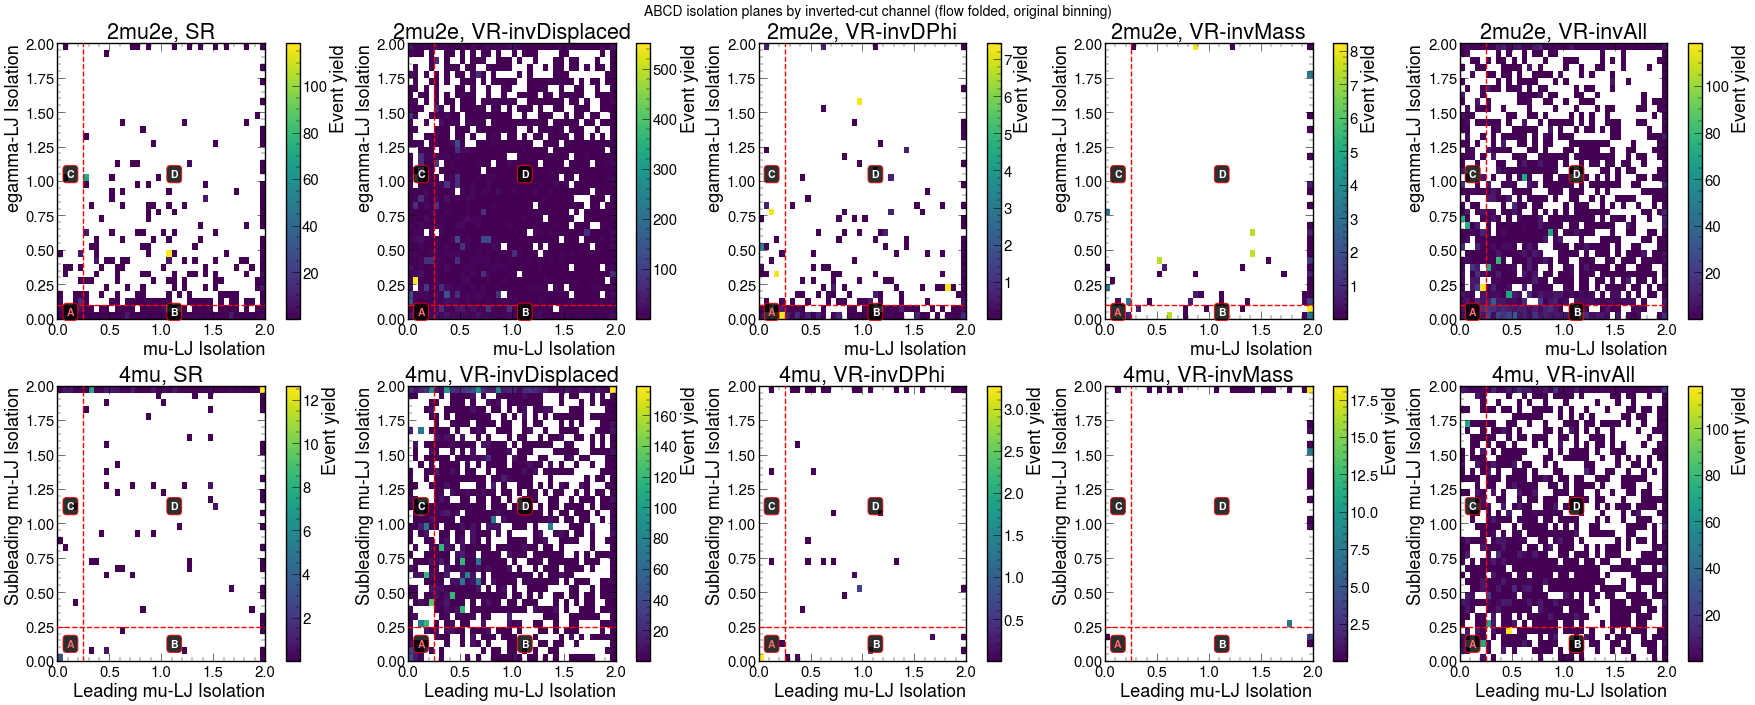

In [4]:
def combined_plane(topology):
    config = TOPOLOGY_CONFIG[topology]
    total = None
    for sample in SAMPLES:
        histogram = out[sample]["hists"][config["plane_hist"]]
        total = histogram.copy() if total is None else total + histogram
    return total


def folded_2d_values(histogram):
    values = np.asarray(histogram.values(flow=True), dtype=float)
    folded = values[1:-1, 1:-1].copy()
    folded[0, :] += values[0, 1:-1]
    folded[-1, :] += values[-1, 1:-1]
    folded[:, 0] += values[1:-1, 0]
    folded[:, -1] += values[1:-1, -1]
    folded[0, 0] += values[0, 0]
    folded[0, -1] += values[0, -1]
    folded[-1, 0] += values[-1, 0]
    folded[-1, -1] += values[-1, -1]
    return folded


fig, axes = plt.subplots(
    len(TOPOLOGY_CONFIG), len(SELECTIONS),
    figsize=(7 * len(SELECTIONS), 7 * len(TOPOLOGY_CONFIG)),
    constrained_layout=True,
)
for row, topology in enumerate(TOPOLOGY_CONFIG):
    for column, selection in enumerate(SELECTIONS):
        ax = axes[row, column]
        config = TOPOLOGY_CONFIG[topology]
        plane = combined_plane(topology)[{"channel": config["channels"][selection]}]
        values = np.abs(folded_2d_values(plane))
        xedges = np.asarray(plane.axes[0].edges)
        yedges = np.asarray(plane.axes[1].edges)
        positive = np.ma.masked_less_equal(values.T, 0)
        mesh = ax.pcolormesh(xedges, yedges, positive, shading="auto")
        xcut, ycut = config["cuts"]
        boundary_color = "red"
        ax.axvline(xcut, color=boundary_color, linestyle="--", linewidth=2, zorder=3)
        ax.axhline(ycut, color=boundary_color, linestyle="--", linewidth=2, zorder=3)

        positions = {
            "A": ((xedges[0] + xcut) / 2, (yedges[0] + ycut) / 2),
            "B": ((xcut + xedges[-1]) / 2, (yedges[0] + ycut) / 2),
            "C": ((xedges[0] + xcut) / 2, (ycut + yedges[-1]) / 2),
            "D": ((xcut + xedges[-1]) / 2, (ycut + yedges[-1]) / 2),
        }
        label_box = dict(
            boxstyle="round,pad=0.35", facecolor="black", edgecolor=boundary_color,
            linewidth=1.5, alpha=0.82,
        )
        for region, (xpos, ypos) in positions.items():
            ax.text(
                xpos, ypos, region, ha="center", va="center", fontsize=15,
                fontweight="bold", color="#FF6B6B" if region == "A" else "white",
                bbox=label_box, zorder=4,
            )

        ax.set(
            xlabel=plane.axes[0].label,
            ylabel=plane.axes[1].label,
            title=f"{topology}, {selection}",
        )
        fig.colorbar(mesh, ax=ax, label="Event yield")
fig.suptitle("ABCD isolation planes by inverted-cut channel (flow folded, original binning)", fontsize=20)
plt.show()
plt.close(fig)


## Helpers

The isolation-plane yield is integrated using bin centers and the same strict pass convention used by the ABCD producer (`iso < cut`). Underflow and overflow are retained. Mother histograms are sliced directly with their stored `abcd_region` axis.

Flow policy: isolation-plane integrations include all flow bins; 2D displays fold them into visible edge bins; mother-PDG flow entries are assigned to `Others`.

In [5]:
MOTHER_CATEGORY_ORDER = [
    "Z", "W", "e", "Muon", r"$\pi$", r"$\eta$/$\omega$",
    "B Meson", "D Meson", "Quark/Gluon", r"J/$\Psi$", "Others",
]

def categorize_background_mother(pdgid):
    abs_id = abs(int(pdgid))
    if abs_id == 23:
        return "Z"
    if abs_id == 24:
        return "W"
    if abs_id == 11:
        return "e"
    if abs_id == 13:
        return "Muon"
    if abs_id in (111, 211):
        return r"$\pi$"
    if abs_id in (221, 223):
        return r"$\eta$/$\omega$"
    if abs_id in (511, 521, 531, 541):
        return "B Meson"
    if abs_id in (411, 421, 423, 431):
        return "D Meson"
    if abs_id in (1, 2, 3, 4, 5, 6, 9, 21):
        return "Quark/Gluon"
    if abs_id == 443:
        return r"J/$\Psi$"
    return "Others"

def values_and_variances(histogram, flow=False):
    values = np.asarray(histogram.values(flow=flow), dtype=float)
    variances = histogram.variances(flow=flow)
    if variances is None:
        variances = np.abs(values)
    else:
        variances = np.asarray(variances, dtype=float)
        variances = np.where(np.isfinite(variances) & (variances >= 0), variances, 0.0)
    return values, variances

def _axis_centers_with_flow(axis):
    centers = np.asarray(axis.centers, dtype=float)
    return np.concatenate(([-np.inf], centers, [np.inf]))

def plane_region_yield(sample, topology, selection, region):
    config = TOPOLOGY_CONFIG[topology]
    channel = config["channels"][selection]
    histogram = out[sample]["hists"][config["plane_hist"]][{"channel": channel}]
    values, variances = values_and_variances(histogram, flow=True)
    xcenters = _axis_centers_with_flow(histogram.axes[0])
    ycenters = _axis_centers_with_flow(histogram.axes[1])
    xpass = xcenters < config["cuts"][0]
    ypass = ycenters < config["cuts"][1]
    masks = {
        "A": xpass[:, None] & ypass[None, :],
        "B": ~xpass[:, None] & ypass[None, :],
        "C": xpass[:, None] & ~ypass[None, :],
        "D": ~xpass[:, None] & ~ypass[None, :],
    }
    mask = masks[region]
    return float(values[mask].sum()), float(variances[mask].sum())

def mother_histogram(sample, topology, role, selection, region):
    config = TOPOLOGY_CONFIG[topology]
    channel = config["channels"][selection]
    role_suffix = config["roles"][role]
    histogram_name = f"fs_gen_mother_id_{role_suffix}_abcd"
    return out[sample]["hists"][histogram_name][{
        "channel": channel,
        "abcd_region": hist.loc(ABCD_REGIONS[region]),
    }]

def categorize_mother_histogram(histogram):
    values, variances = values_and_variances(histogram, flow=True)
    centers = np.asarray(histogram.axes[0].centers, dtype=int)
    yields = defaultdict(float)
    category_variances = defaultdict(float)
    for pdgid, value, variance in zip(centers, values[1:-1], variances[1:-1]):
        category = categorize_background_mother(pdgid)
        yields[category] += float(value)
        category_variances[category] += float(variance)
    # Exact PDG categories outside the stored axis range are unavailable.
    yields["Others"] += float(values[0] + values[-1])
    category_variances["Others"] += float(variances[0] + variances[-1])
    return yields, category_variances

def region_labels(topology):
    return [f"{selection}-{region}" for selection in SELECTIONS for region in ABCD_REGIONS]

def safe_fractions(table):
    totals = table.sum(axis=1)
    return table.div(totals.replace(0, np.nan), axis=0).fillna(0.0)

def plot_stacked_table(table, title, ylabel, logy=False, colors=None, figsize=(24, 12)):
    ax = table.plot(
        kind="bar", stacked=True, figsize=figsize,
        color=colors, edgecolor="black", linewidth=0.4,
    )
    if logy:
        ax.set_yscale("log")
    ax.set(title=title, xlabel="Region", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_fraction_heatmap(table, title, figsize=(24, 12)):
    fig, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(table.T.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(table.index)), labels=table.index, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.columns)), labels=table.columns)
    ax.set(title=title, xlabel="Region", ylabel="Mother category")
    fig.colorbar(image, ax=ax, label="Fraction of mother-object yield")
    plt.tight_layout()
    plt.show()
    plt.close()

## Event yield tables by ABCD region

These tables contain event yield only; they do not use mother information. They are retained as numerical references, while the region-by-region visualization is shown only as background-process fractions in the next section.

In [6]:
sample_landing_yields = {}
group_landing_yields = {}
group_landing_errors = {}

for topology in TOPOLOGY_CONFIG:
    sample_rows = []
    for selection in SELECTIONS:
        for region in ABCD_REGIONS:
            label = f"{selection}-{region}"
            row = {"region": label}
            for sample in SAMPLES:
                value, variance = plane_region_yield(sample, topology, selection, region)
                row[sample] = value
            sample_rows.append(row)
    sample_table = pd.DataFrame(sample_rows).set_index("region")
    sample_landing_yields[topology] = sample_table

    grouped = pd.DataFrame(index=sample_table.index)
    grouped_errors = pd.DataFrame(index=sample_table.index)
    for group, samples in BACKGROUND_GROUPS.items():
        grouped[group] = sample_table[samples].sum(axis=1)
        variances = []
        for selection in SELECTIONS:
            for region in ABCD_REGIONS:
                variances.append(sum(
                    plane_region_yield(sample, topology, selection, region)[1]
                    for sample in samples
                ))
        grouped_errors[group] = np.sqrt(variances)
    group_landing_yields[topology] = grouped
    group_landing_errors[topology] = grouped_errors

    display(Markdown(f"### {topology}: grouped background landing yield"))
    display(grouped.round(4))
    display(Markdown(f"### {topology}: individual sample landing yield"))
    display(sample_table.round(4))


### 2mu2e: grouped background landing yield

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0000,0.0000,6.4961,23.8852
SR-B,0.0000,3.2737,0.0000,108.4937
SR-C,0.0000,6.5473,0.0000,24.2814
SR-D,0.0000,6.5473,0.0000,246.5217
VR-invDisplaced-A,7.8616,72.0204,9.7441,9.7165
VR-invDisplaced-B,1.4172,383.0176,19.4882,298.3710
VR-invDisplaced-C,2.4103,39.2839,188.0210,1796.4197
VR-invDisplaced-D,0.6095,225.8822,12.9922,4376.2510
VR-invDPhi-A,0.0000,0.0000,0.0000,15.7540


### 2mu2e: individual sample landing yield

,TTJets,QCD_Pt15To20,QCD_Pt20To30,QCD_Pt30To50,QCD_Pt50To80,QCD_Pt80To120,QCD_Pt120To170,QCD_Pt170To300,QCD_Pt300To470,QCD_Pt470To600,QCD_Pt600To800,QCD_Pt800To1000,QCD_Pt1000,DYJetsToLL_M10to50,DYJetsToLL_M50,WW,WZ,ZZ
region,,,,,,,,,,,,,,,,,,
SR-A,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,21.9825,1.3175,0.3743,0.1750,0.0257,0.0101,0.0000,6.4961,0.0000,0.0000,0.0000
SR-B,3.2737,0.0,0.0,0.0,0.0000,0.0000,70.4988,21.9825,10.5396,3.1814,1.6629,0.3985,0.2299,0.0000,0.0000,0.0000,0.0000,0.0000
SR-C,6.5473,0.0,0.0,0.0,0.0000,0.0000,0.0000,21.9825,1.9762,0.1871,0.1167,0.0154,0.0034,0.0000,0.0000,0.0000,0.0000,0.0000
SR-D,6.5473,0.0,0.0,0.0,0.0000,118.3545,70.4988,36.6376,17.1269,2.0586,1.3129,0.3805,0.1521,0.0000,0.0000,0.0000,0.0000,0.0000
VR-invDisplaced-A,72.0204,0.0,0.0,0.0,0.0000,0.0000,0.0000,7.3275,1.9762,0.2807,0.1167,0.0154,0.0000,0.0000,9.7441,0.8056,3.5141,3.5419
VR-invDisplaced-B,383.0176,0.0,0.0,0.0,0.0000,0.0000,211.4963,58.6201,22.3967,3.5557,1.8380,0.3188,0.1454,0.0000,19.4882,0.0000,0.8268,0.5903
VR-invDisplaced-C,39.2839,0.0,0.0,0.0,537.6994,236.7089,563.9901,410.3407,41.4998,4.4914,1.3129,0.2751,0.1014,152.2926,35.7284,0.4028,0.8268,1.1806
VR-invDisplaced-D,225.8822,0.0,0.0,0.0,0.0000,473.4179,1480.4741,1839.2055,470.9897,74.5757,29.3204,6.1447,2.1230,0.0000,12.9922,0.4028,0.2067,0.0000
VR-invDPhi-A,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,14.6550,0.6587,0.3743,0.0292,0.0334,0.0034,0.0000,0.0000,0.0000,0.0000,0.0000


### 4mu: grouped background landing yield

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0000,0.0000,3.2480,0.0026
SR-B,0.0000,0.0000,0.0000,0.7495
SR-C,0.0000,0.0000,0.0000,1.6717
SR-D,0.0000,3.2737,0.0000,25.3002
VR-invDisplaced-A,2.2043,3.2737,123.4255,10.1813
VR-invDisplaced-B,0.0000,6.5473,3.2480,74.9061
VR-invDisplaced-C,0.3935,22.9156,38.5248,938.0171
VR-invDisplaced-D,0.0000,65.4731,3.2480,2763.2175
VR-invDPhi-A,0.0000,3.2737,0.0000,0.0051


### 4mu: individual sample landing yield

,TTJets,QCD_Pt15To20,QCD_Pt20To30,QCD_Pt30To50,QCD_Pt50To80,QCD_Pt80To120,QCD_Pt120To170,QCD_Pt170To300,QCD_Pt300To470,QCD_Pt470To600,QCD_Pt600To800,QCD_Pt800To1000,QCD_Pt1000,DYJetsToLL_M10to50,DYJetsToLL_M50,WW,WZ,ZZ
region,,,,,,,,,,,,,,,,,,
SR-A,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0026,0.0000,0.0000,3.2480,0.0,0.0000,0.0000
SR-B,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.6587,0.0000,0.0583,0.0257,0.0068,0.0000,0.0000,0.0,0.0000,0.0000
SR-C,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,1.3175,0.0936,0.2042,0.0463,0.0101,0.0000,0.0000,0.0,0.0000,0.0000
SR-D,3.2737,0.0,0.0,0.0,0.0,0.0000,0.0000,14.6550,5.9285,2.1521,1.4587,0.6967,0.4091,0.0000,0.0000,0.0,0.0000,0.0000
VR-invDisplaced-A,3.2737,0.0,0.0,0.0,0.0,0.0000,0.0000,7.3275,2.6349,0.1871,0.0292,0.0026,0.0000,0.0000,123.4255,0.0,0.8268,1.3774
VR-invDisplaced-B,6.5473,0.0,0.0,0.0,0.0,0.0000,0.0000,65.9476,5.9285,1.8714,0.7877,0.2288,0.1420,0.0000,3.2480,0.0,0.0000,0.0000
VR-invDisplaced-C,22.9156,0.0,0.0,0.0,0.0,355.0634,352.4938,197.8428,26.3491,3.9300,1.6921,0.4396,0.2062,19.0366,19.4882,0.0,0.0000,0.3935
VR-invDisplaced-D,65.4731,0.0,0.0,0.0,0.0,473.4179,704.9877,1106.4543,342.5380,75.9792,41.6029,12.0477,6.1899,0.0000,3.2480,0.0,0.0000,0.0000
VR-invDPhi-A,3.2737,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0051,0.0000,0.0000,0.0000,0.0,0.0000,0.0000


## Background-process composition by ABCD region

This is the QCD/DY/TT/Diboson fraction of the event yield in each region. It is not generator-mother composition. Region-by-region composition is visualized only as fractions; the main yield visualization is the Inclusive/Signal-like/Bkg-like comparison below.

### 2mu2e: background-source fractions

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0%,0.0%,21.38%,78.62%
SR-B,0.0%,2.93%,0.0%,97.07%
SR-C,0.0%,21.24%,0.0%,78.76%
SR-D,0.0%,2.59%,0.0%,97.41%
VR-invDisplaced-A,7.91%,72.5%,9.81%,9.78%
VR-invDisplaced-B,0.2%,54.54%,2.77%,42.49%
VR-invDisplaced-C,0.12%,1.94%,9.28%,88.66%
VR-invDisplaced-D,0.01%,4.89%,0.28%,94.81%
VR-invDPhi-A,0.0%,0.0%,0.0%,100.0%


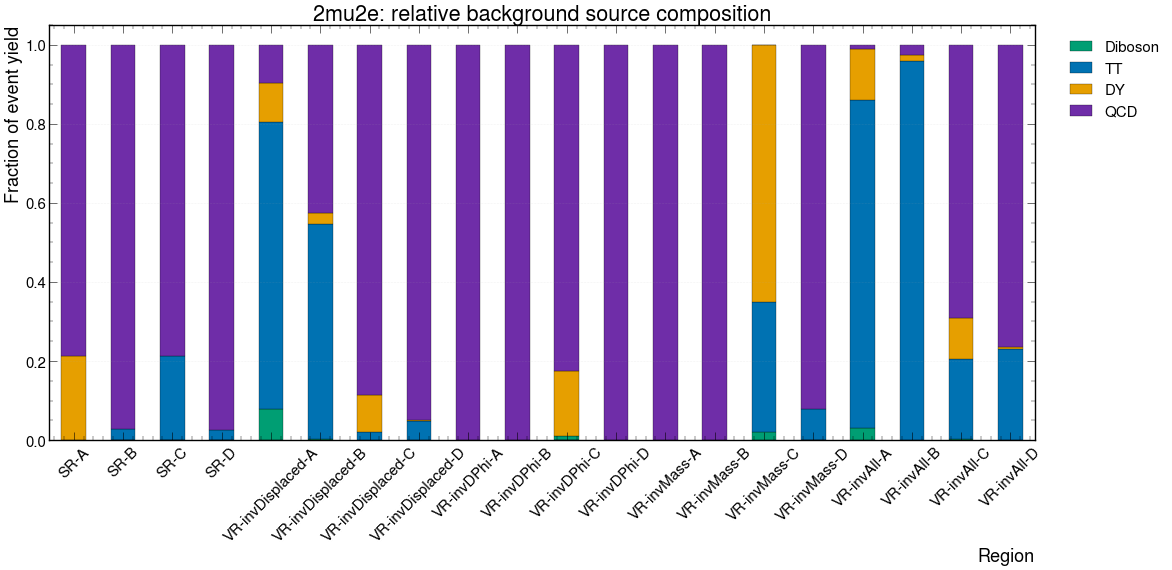

### 4mu: background-source fractions

,Diboson,TT,DY,QCD
region,,,,
SR-A,0.0%,0.0%,99.92%,0.08%
SR-B,0.0%,0.0%,0.0%,100.0%
SR-C,0.0%,0.0%,0.0%,100.0%
SR-D,0.0%,11.46%,0.0%,88.54%
VR-invDisplaced-A,1.58%,2.35%,88.74%,7.32%
VR-invDisplaced-B,0.0%,7.73%,3.83%,88.44%
VR-invDisplaced-C,0.04%,2.29%,3.85%,93.82%
VR-invDisplaced-D,0.0%,2.31%,0.11%,97.57%
VR-invDPhi-A,0.0%,99.84%,0.0%,0.16%


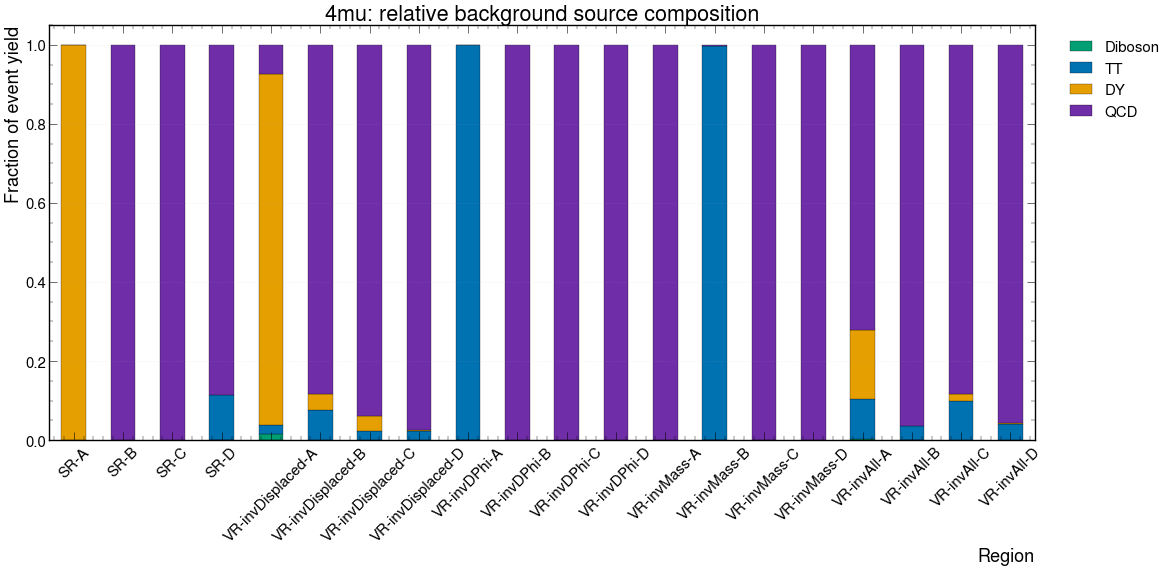

In [7]:
group_landing_fractions = {}
for topology, yield_table in group_landing_yields.items():
    fraction_table = safe_fractions(yield_table)
    group_landing_fractions[topology] = fraction_table
    display(Markdown(f"### {topology}: background-source fractions"))
    display((100 * fraction_table).round(2).astype(str) + "%")
    plot_stacked_table(
        fraction_table,
        f"{topology}: relative background source composition",
        "Fraction of event yield",
        colors=[GROUP_COLORS[group] for group in fraction_table.columns],
    )

In [8]:
def ratio_uncertainty(numerator, numerator_error, denominator, denominator_error):
    numerator = np.asarray(numerator, dtype=float)
    numerator_error = np.asarray(numerator_error, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    denominator_error = np.asarray(denominator_error, dtype=float)
    ratio = np.full(numerator.shape, np.nan, dtype=float)
    error = np.full(numerator.shape, np.nan, dtype=float)
    valid = (
        np.isfinite(numerator) & np.isfinite(numerator_error)
        & np.isfinite(denominator) & np.isfinite(denominator_error)
        & (denominator > 0)
    )
    ratio[valid] = numerator[valid] / denominator[valid]
    positive = valid & (numerator > 0)
    error[positive] = ratio[positive] * np.sqrt(
        (numerator_error[positive] / numerator[positive]) ** 2
        + (denominator_error[positive] / denominator[positive]) ** 2
    )
    zero = valid & (numerator == 0)
    error[zero] = numerator_error[zero] / denominator[zero]
    return ratio, error


def plot_event_signal_background_ratio(table, title):
    x = np.arange(len(table.index))
    fig, (ax, rax) = plt.subplots(
        2, 1, figsize=(24, 12), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )
    for index, process in enumerate(table.index):
        color = GROUP_COLORS[process]
        inclusive = table.loc[process, "Inclusive"]
        inclusive_error = table.loc[process, "Inclusive error"]
        signal_like = table.loc[process, "Signal-like (A)"]
        signal_error = table.loc[process, "Signal-like error"]
        background_like = table.loc[process, "Bkg-like (D)"]
        background_error = table.loc[process, "Bkg-like error"]
        ax.bar(x[index], inclusive, color=color, edgecolor="black", width=0.65, label=process)
        if inclusive > 0:
            ax.errorbar(x[index], inclusive, yerr=inclusive_error, fmt="none", ecolor="black", capsize=4)
        if signal_like > 0:
            ax.errorbar(x[index], signal_like, yerr=signal_error, marker="o", markerfacecolor="none",
                        markeredgecolor="red", ecolor="red", capsize=4, linestyle="none")
        if background_like > 0:
            ax.errorbar(x[index], background_like, yerr=background_error, marker="x",
                        color="blue", ecolor="blue", capsize=4, linestyle="none")
        for value, error, marker, color_name in (
            (table.loc[process, "A / Inclusive"], table.loc[process, "A / Inclusive error"], "o", "red"),
            (table.loc[process, "D / Inclusive"], table.loc[process, "D / Inclusive error"], "x", "blue"),
        ):
            if np.isfinite(value):
                rax.errorbar(x[index], value, yerr=error, marker=marker, markerfacecolor="none" if marker == "o" else color_name,
                             color=color_name, ecolor=color_name, capsize=4, linestyle="none")
    ax.set_yscale("log")
    ax.set(title=title, ylabel="Event yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    from matplotlib.lines import Line2D
    region_handles = [
        Line2D([], [], marker="o", markerfacecolor="none", color="red", linestyle="none", label="Signal-like (A)"),
        Line2D([], [], marker="x", color="blue", linestyle="none", label="Bkg-like (D)"),
    ]
    process_legend = ax.legend(title="Process", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.add_artist(process_legend)
    ax.legend(handles=region_handles, title="Region", bbox_to_anchor=(1.02, 0.55), loc="upper left")
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Background process", ylim=(0, 1.15))
    rax.set_xticks(x, table.index, rotation=30, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Signal-like and background-like event-yield ratios

Following notebook `02`, `A` (both isolation values pass) is signal-like and `D` (both fail) is background-like. For each configured SR/VR selection the inclusive denominator is `A+B+C+D`. Error bars use summed histogram variances and the same ratio propagation used in `02`.

### 2mu2e, SR: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
TT,16.36827,7.32011,0.00000,0.00000,6.54731,4.62965,0.00000,0.00000,0.40000,0.33466
DY,6.49608,4.59342,6.49608,4.59342,0.00000,0.00000,1.00000,1.00000,0.00000,0.00000
QCD,403.18193,157.22806,23.88517,12.72735,246.52173,138.77259,0.05924,0.03912,0.61144,0.41872


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


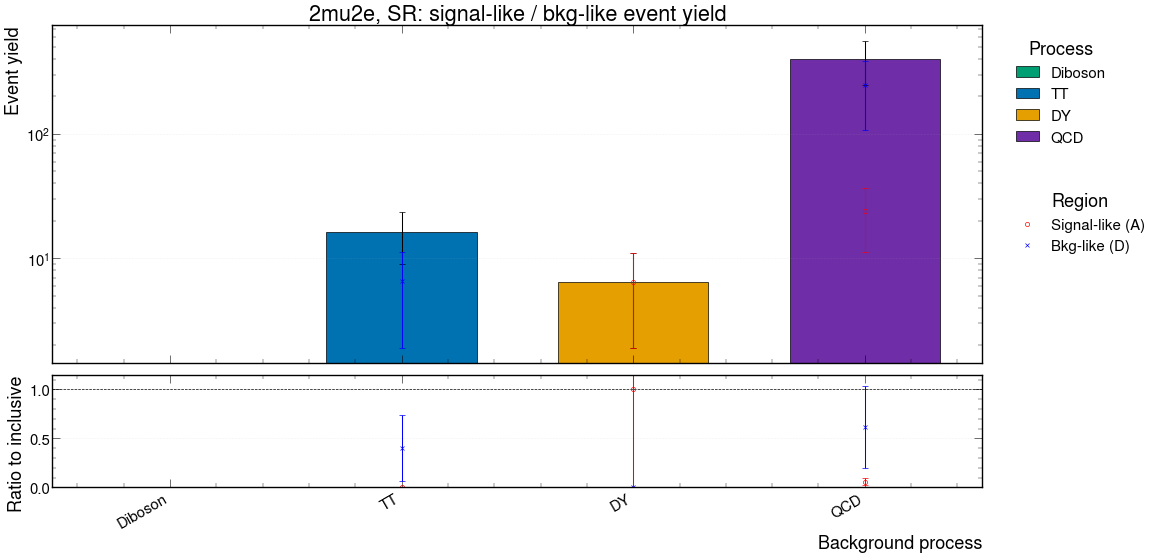

### 2mu2e, VR-invDisplaced: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,12.29863,1.67494,7.86165,1.32207,0.60952,0.45275,0.63923,0.13833,0.04956,0.03743
TT,720.20405,48.55615,72.02041,15.35480,225.88218,27.19302,0.10000,0.02236,0.31364,0.04328
DY,230.24550,41.26449,9.74412,5.62577,12.99216,6.49608,0.04232,0.02558,0.05643,0.02997
QCD,6480.75812,741.30893,9.71653,7.41781,4376.25097,417.36989,0.00150,0.00116,0.67527,0.10057


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


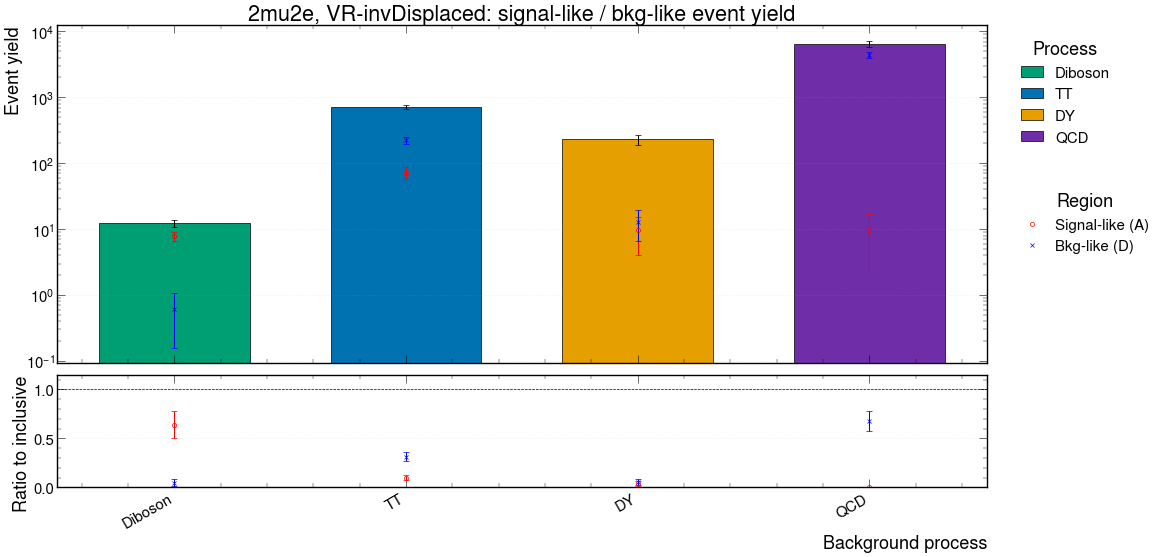

### 2mu2e, VR-invDPhi: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.19677,0.19677,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000
TT,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,NaN,NaN,NaN,NaN
DY,3.24804,3.24804,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000
QCD,62.50217,18.19820,15.75401,10.38531,22.53659,10.5549,0.25206,0.18164,0.36057,0.19885


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


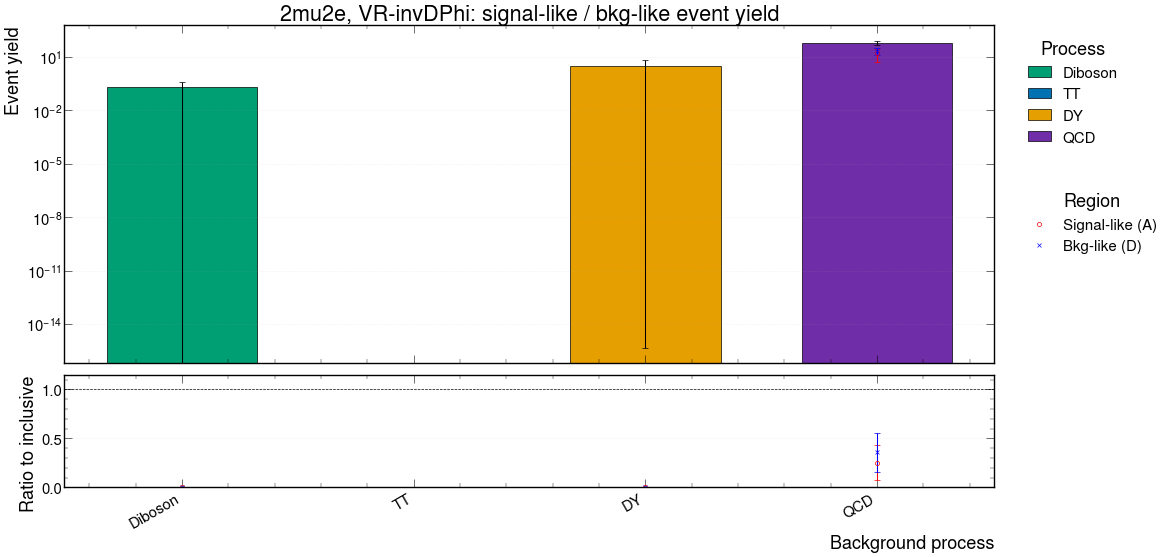

### 2mu2e, VR-invMass: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.20671,0.20671,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
TT,6.54731,4.62965,0.00000,0.00000,3.27365,3.27365,0.00000,0.00000,0.50000,0.61237
DY,6.49608,4.59342,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
QCD,57.74254,18.16800,0.65873,0.65873,37.88734,14.81981,0.01141,0.01196,0.65614,0.32938


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


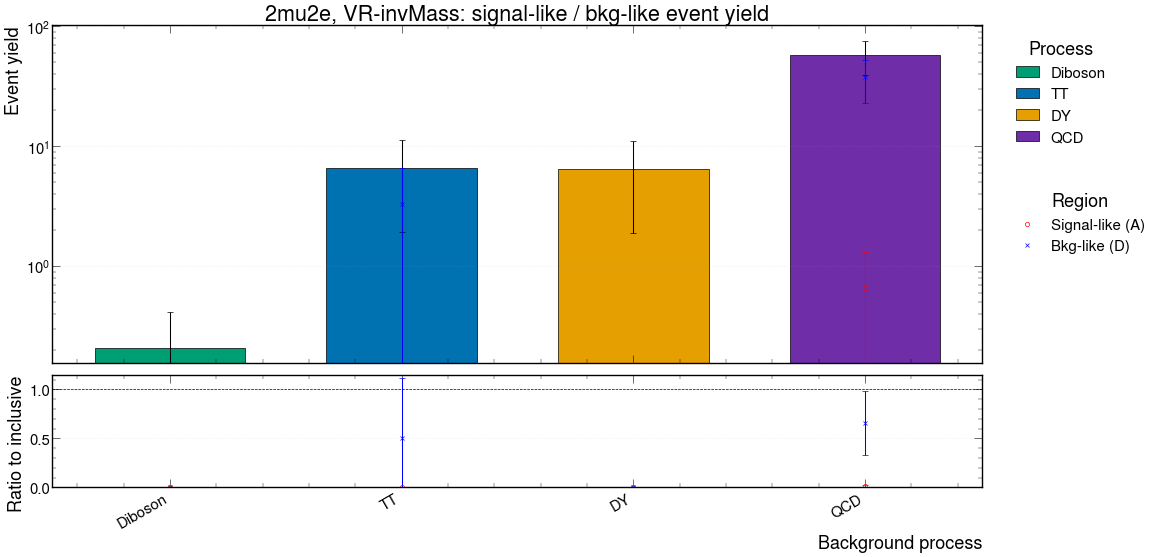

### 2mu2e, VR-invAll: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,3.81753,0.92117,2.20359,0.72302,0.00000,0.00000,0.57723,0.23510,0.00000,0.00000
TT,910.07603,54.58273,62.19944,14.26953,301.17624,31.39979,0.06835,0.01621,0.33094,0.03980
DY,83.54569,22.58512,9.74412,5.62577,6.49608,4.59342,0.11663,0.07435,0.07775,0.05886
QCD,1416.08544,230.35417,0.76339,0.66536,1000.65617,167.88273,0.00054,0.00048,0.70664,0.16513


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


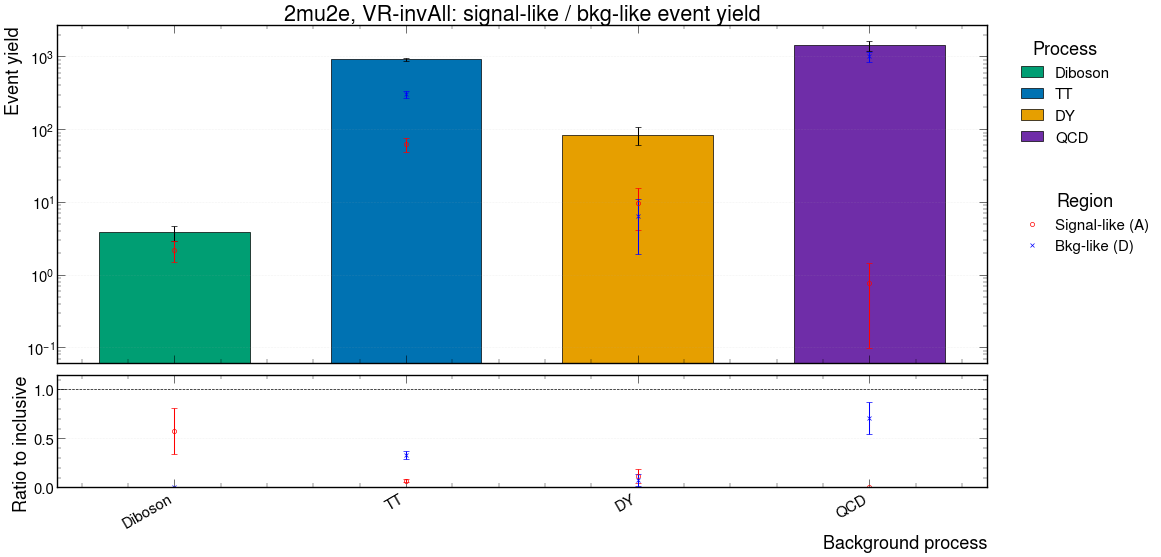

### 4mu, SR: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
TT,3.27365,3.27365,0.00000,0.00000,3.27365,3.27365,0.00000,0.00000,1.00000,1.41421
DY,3.24804,3.24804,3.24804,3.24804,0.00000,0.00000,1.00000,1.41421,0.00000,0.00000
QCD,27.72399,10.62336,0.00257,0.00257,25.30021,10.56112,0.00009,0.00010,0.91257,0.51710


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


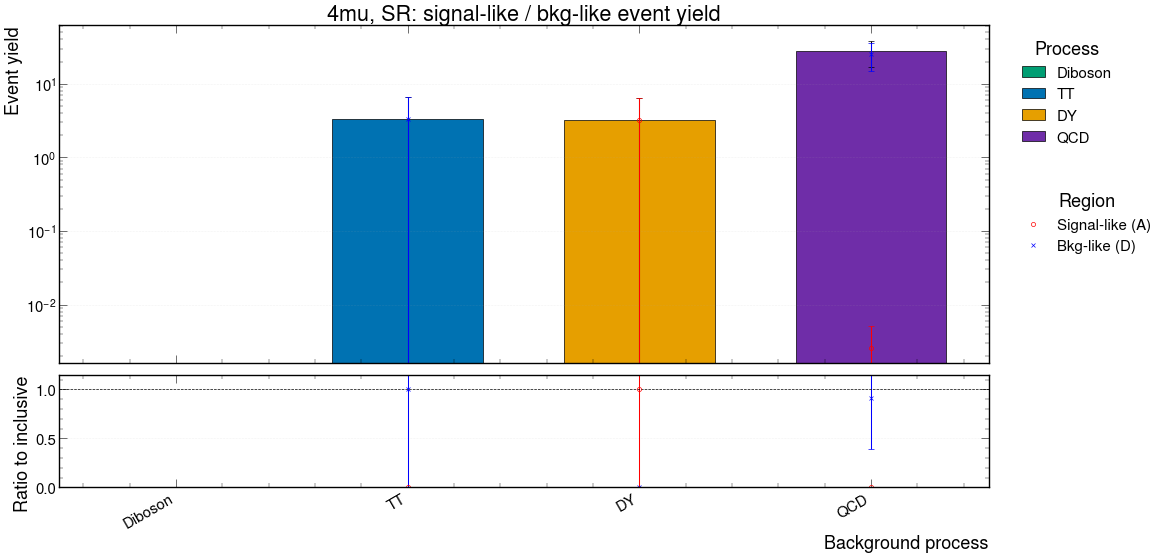

### 4mu, VR-invDisplaced: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,2.59782,0.72069,2.20427,0.66480,0.00000,0.00000,0.84851,0.34771,0.00000,0.00000
TT,98.20964,17.93055,3.27365,3.27365,65.47310,14.64023,0.03333,0.03388,0.66667,0.19245
DY,168.44639,25.81636,123.42550,20.02226,3.24804,3.24804,0.73273,0.16352,0.01928,0.01951
QCD,3786.32196,427.73523,10.18131,7.44624,2763.21751,337.74761,0.00269,0.00199,0.72979,0.12147


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


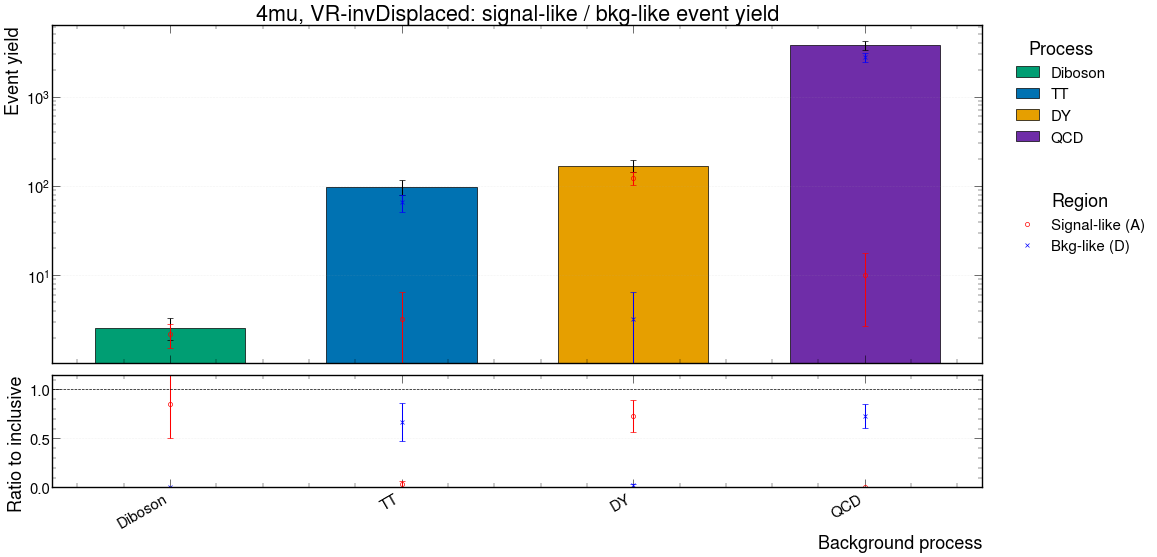

### 4mu, VR-invDPhi: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
TT,3.27365,3.27365,3.27365,3.27365,0.00000,0.00000,1.00000,1.41421,0.00000,0.00000
DY,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
QCD,1.81471,0.94752,0.00514,0.00364,0.94665,0.66806,0.00283,0.00249,0.52166,0.45794


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


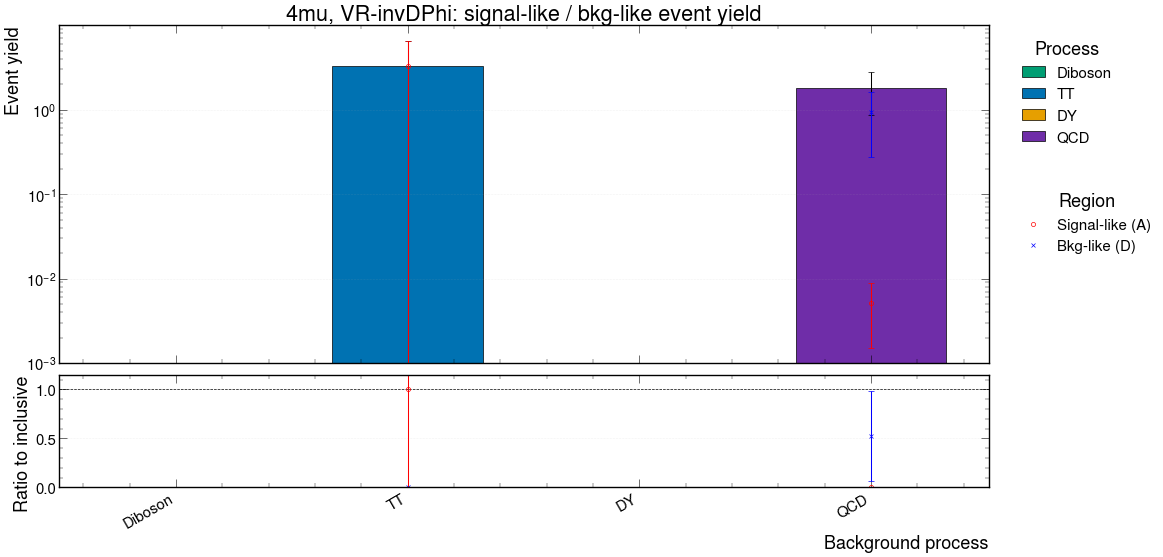

### 4mu, VR-invMass: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
TT,3.27365,3.27365,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000
DY,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,NaN,NaN,NaN,NaN
QCD,35.07203,14.73397,0.00257,0.00257,35.03352,14.73394,0.00007,0.00008,0.9989,0.59379


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


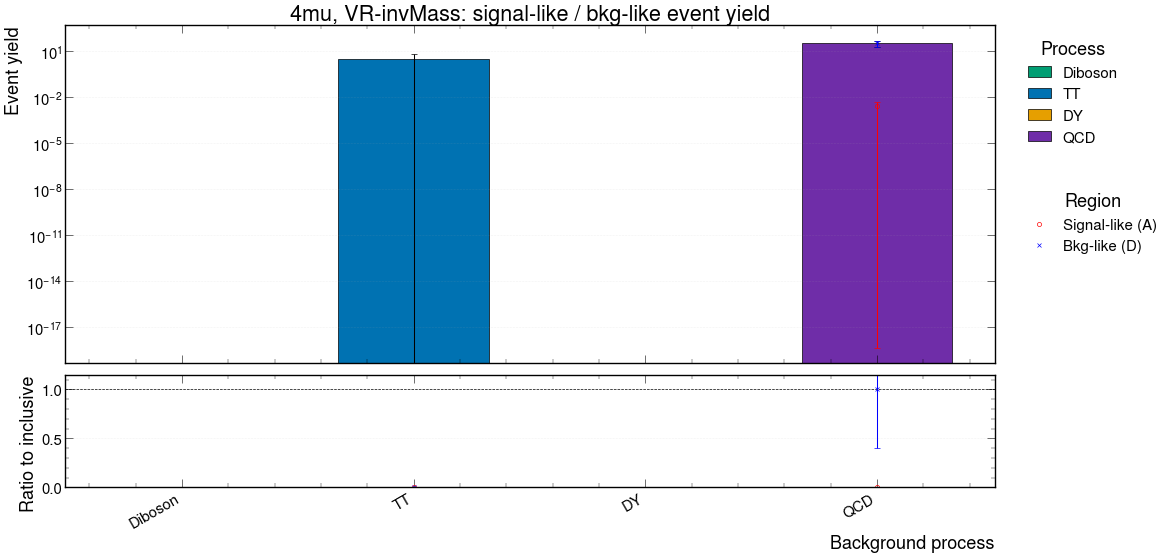

### 4mu, VR-invAll: event yield and A/D ratios

,Inclusive,Inclusive error,Signal-like (A),Signal-like error,Bkg-like (D),Bkg-like error,A / Inclusive,A / Inclusive error,D / Inclusive,D / Inclusive error
process,,,,,,,,,,
Diboson,1.03355,0.46222,0.41342,0.29233,0.41342,0.29233,0.40000,0.33466,0.40000,0.33466
TT,72.02041,15.35480,13.09462,6.54731,32.73655,10.35221,0.18182,0.09883,0.45455,0.17336
DY,29.00652,12.40550,22.51044,11.52375,3.24804,3.24804,0.77605,0.51768,0.11198,0.12179
QCD,1228.29829,183.88300,93.43603,71.63528,785.77283,93.66703,0.07607,0.05942,0.63972,0.12242


/tmp/ipykernel_2975/1233283583.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


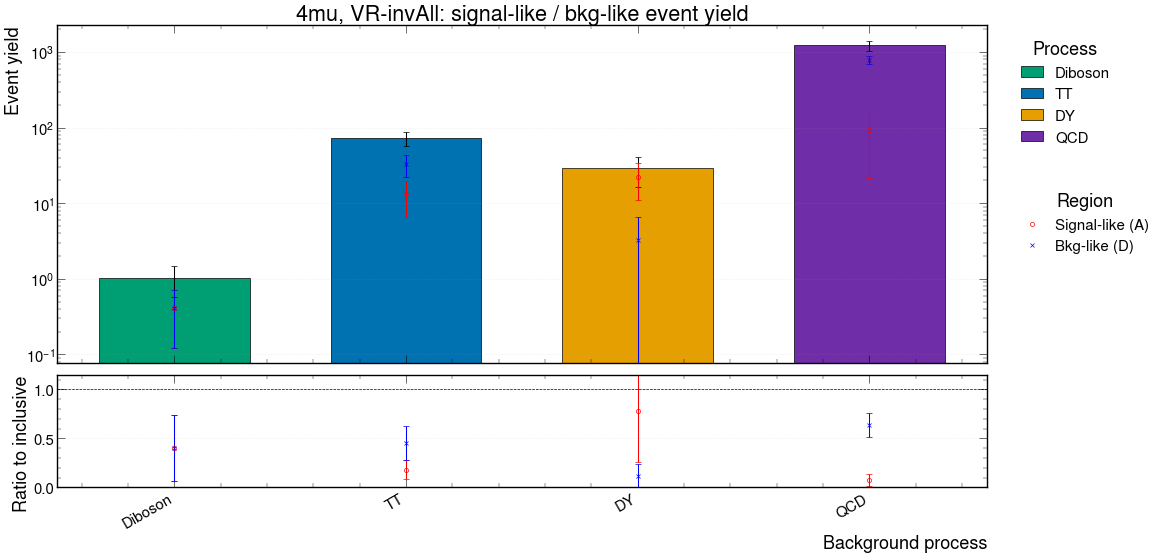

In [9]:
event_region_ratio_tables = {}
for topology in TOPOLOGY_CONFIG:
    event_region_ratio_tables[topology] = {}
    for selection in SELECTIONS:
        rows = []
        for group, samples in BACKGROUND_GROUPS.items():
            yields = {}
            variances = {}
            for region in ABCD_REGIONS:
                values = [plane_region_yield(sample, topology, selection, region) for sample in samples]
                yields[region] = sum(value for value, _ in values)
                variances[region] = sum(variance for _, variance in values)
            inclusive = sum(yields.values())
            inclusive_variance = sum(variances.values())
            a_ratio, a_ratio_error = ratio_uncertainty(
                [yields["A"]], [np.sqrt(variances["A"])], [inclusive], [np.sqrt(inclusive_variance)]
            )
            d_ratio, d_ratio_error = ratio_uncertainty(
                [yields["D"]], [np.sqrt(variances["D"])], [inclusive], [np.sqrt(inclusive_variance)]
            )
            rows.append({
                "process": group,
                "Inclusive": inclusive,
                "Inclusive error": np.sqrt(inclusive_variance),
                "Signal-like (A)": yields["A"],
                "Signal-like error": np.sqrt(variances["A"]),
                "Bkg-like (D)": yields["D"],
                "Bkg-like error": np.sqrt(variances["D"]),
                "A / Inclusive": a_ratio[0],
                "A / Inclusive error": a_ratio_error[0],
                "D / Inclusive": d_ratio[0],
                "D / Inclusive error": d_ratio_error[0],
            })
        table = pd.DataFrame(rows).set_index("process")
        event_region_ratio_tables[topology][selection] = table
        display(Markdown(f"### {topology}, {selection}: event yield and A/D ratios"))
        display(table.round(5))
        plot_event_signal_background_ratio(table, f"{topology}, {selection}: signal-like / bkg-like event yield")

## Mother composition by LJ role and ABCD region

All background samples are combined. Numerical mother-object yields are retained in tables, while the region-by-region visualization is shown only as fraction heatmaps. Yield plots are reserved for the later Inclusive/Signal-like/Bkg-like process comparison.

All tables and heatmaps use one common mother-category order determined from the total mother-object yield over every topology, configured selection, ABCD region, and LJ role.

### Common mother stack order (bottom → top)

,global mother-object yield
Muon,516.486778
Z,524.718043
e,736.094087
W,1949.112948
$\eta$/$\omega$,3230.065432
J/$\Psi$,5542.783060
Quark/Gluon,6058.096506
Others,9332.701817
D Meson,27822.902783
B Meson,28420.258785


### 2mu2e, mu-LJ: mother-object yield

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.0000,6.4961,0.0000,0.0000,0.1356,0.1923,15.9776,0.1414,31.2452,46.3071,17.0434
SR-B,0.0026,0.0000,0.0000,0.0000,5.5788,0.0992,2.3903,7.2685,210.4082,211.6940,86.8411
SR-C,3.2737,0.0000,0.0000,3.2737,6.5765,1.3175,1.3226,0.0317,32.4563,61.7106,34.2494
SR-D,0.0000,0.0000,0.0000,0.0000,258.6222,1.5851,22.0543,17.8029,277.4580,213.0709,91.5566
VR-invDisplaced-A,19.9996,14.4860,3.4448,36.0102,3.9324,20.2425,13.8271,45.4550,67.0707,104.1997,7.9477
VR-invDisplaced-B,59.1517,0.5903,0.0000,108.2373,33.9182,107.8167,181.4519,229.9041,950.8657,846.5383,514.5442
VR-invDisplaced-C,106.9074,74.4100,0.0000,26.3959,175.1359,382.6775,2076.6956,950.9115,1389.2566,1228.0863,1315.5720
VR-invDisplaced-D,55.3004,0.0000,3.2737,101.4833,554.3331,1475.0707,1109.6654,2155.3283,6680.5386,6170.6447,4108.2971
VR-invDPhi-A,0.0000,0.0000,0.0000,0.0000,0.1897,0.0000,0.8793,30.0638,23.9935,38.2785,17.1743


### 2mu2e, mu-LJ: mother composition (%)

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.00,5.53,0.00,0.00,0.12,0.16,13.59,0.12,26.58,39.40,14.50
SR-B,0.00,0.00,0.00,0.00,1.06,0.02,0.46,1.39,40.13,40.38,16.56
SR-C,2.27,0.00,0.00,2.27,4.56,0.91,0.92,0.02,22.51,42.79,23.75
SR-D,0.00,0.00,0.00,0.00,29.32,0.18,2.50,2.02,31.45,24.15,10.38
VR-invDisplaced-A,5.94,4.30,1.02,10.70,1.17,6.01,4.11,13.50,19.93,30.96,2.36
VR-invDisplaced-B,1.95,0.02,0.00,3.57,1.12,3.55,5.98,7.58,31.35,27.91,16.96
VR-invDisplaced-C,1.38,0.96,0.00,0.34,2.27,4.95,26.88,12.31,17.98,15.90,17.03
VR-invDisplaced-D,0.25,0.00,0.01,0.45,2.47,6.58,4.95,9.62,29.81,27.53,18.33
VR-invDPhi-A,0.00,0.00,0.00,0.00,0.17,0.00,0.80,27.19,21.70,34.62,15.53


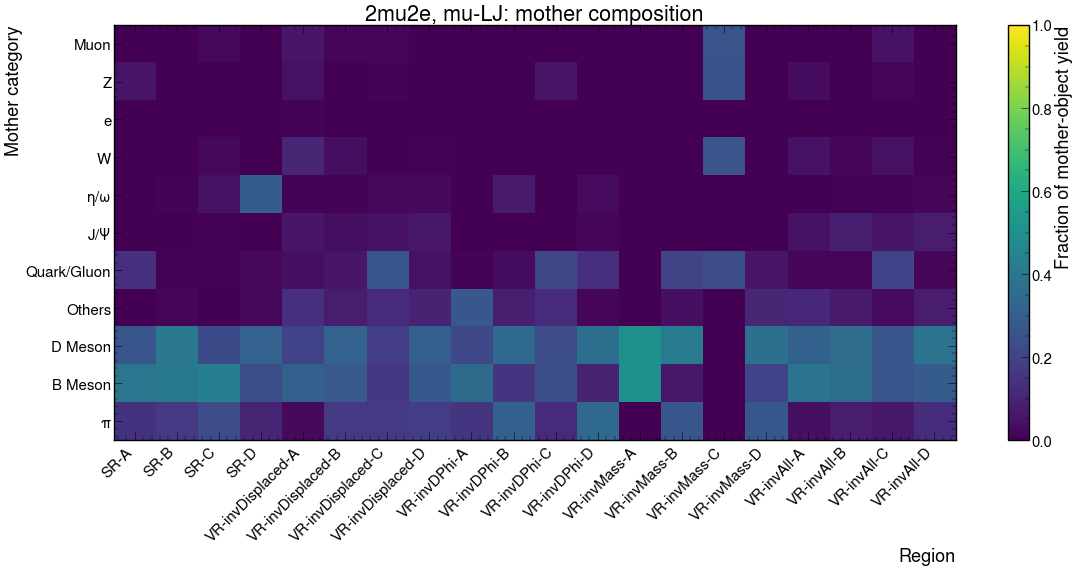

### 2mu2e, egm-LJ: mother-object yield

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.0000,0.0000,0.0000,0.0000,3.2480,0.0000,8.9951,7.9914,0.0000,0.0000,30.1871
SR-B,0.0000,0.0000,0.0000,0.0000,0.2034,0.0000,22.2028,15.6981,0.0188,0.0583,315.5426
SR-C,0.0000,0.0000,0.0000,0.0000,10.6887,0.0000,8.0308,0.1227,8.0519,0.0703,75.9568
SR-D,0.0000,0.0000,0.0000,0.0000,74.5155,0.0000,15.0778,9.9291,0.1712,24.2220,359.6397
VR-invDisplaced-A,0.0000,9.8413,63.0757,73.6866,0.0103,0.0000,8.0180,11.6295,6.5473,2.7516,15.3417
VR-invDisplaced-B,0.0000,20.4820,161.3517,406.3466,25.0273,0.0000,98.8194,33.9393,18.8844,19.4998,715.6206
VR-invDisplaced-C,0.0000,0.5903,14.3044,24.1452,133.4750,0.1167,146.2235,223.9349,396.5450,1173.0164,3632.7511
VR-invDisplaced-D,0.0000,6.4961,63.0218,121.7347,437.8361,32.1354,267.8262,851.8242,1664.3150,2549.1088,7999.7541
VR-invDPhi-A,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9840,0.0000,0.0000,0.0051,0.1098


### 2mu2e, egm-LJ: mother composition (%)

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.00,0.00,0.00,0.00,6.44,0.00,17.84,15.85,0.00,0.00,59.87
SR-B,0.00,0.00,0.00,0.00,0.06,0.00,6.28,4.44,0.01,0.02,89.21
SR-C,0.00,0.00,0.00,0.00,10.39,0.00,7.80,0.12,7.82,0.07,73.80
SR-D,0.00,0.00,0.00,0.00,15.41,0.00,3.12,2.05,0.04,5.01,74.37
VR-invDisplaced-A,0.00,5.16,33.04,38.60,0.01,0.00,4.20,6.09,3.43,1.44,8.04
VR-invDisplaced-B,0.00,1.37,10.76,27.09,1.67,0.00,6.59,2.26,1.26,1.30,47.71
VR-invDisplaced-C,0.00,0.01,0.25,0.42,2.32,0.00,2.55,3.90,6.90,20.42,63.23
VR-invDisplaced-D,0.00,0.05,0.45,0.87,3.13,0.23,1.91,6.09,11.89,18.22,57.17
VR-invDPhi-A,0.00,0.00,0.00,0.00,0.00,0.00,89.54,0.00,0.00,0.47,9.99


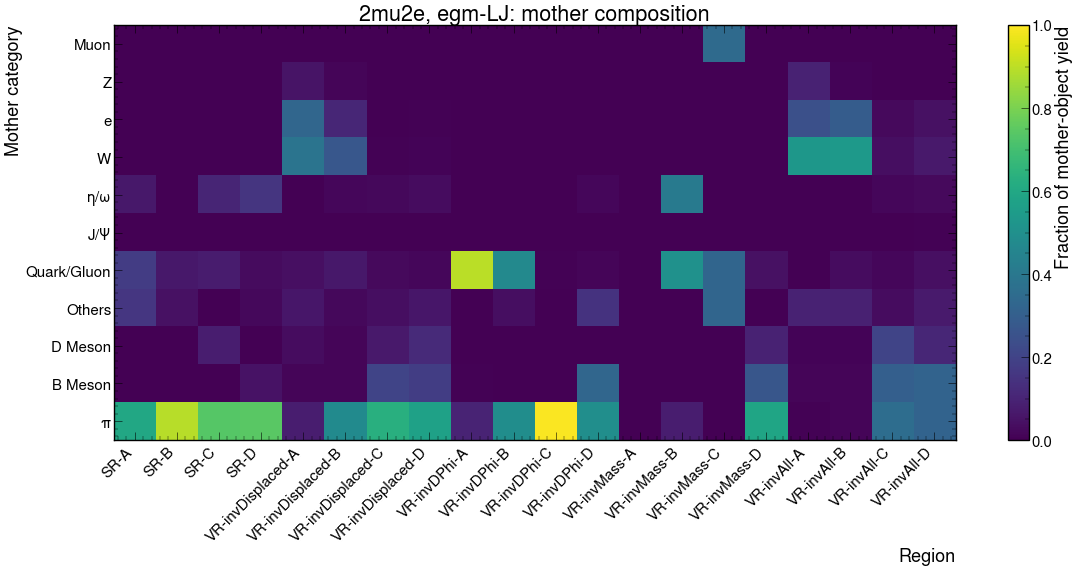

### 4mu, leading mu-LJ: mother-object yield

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.0000,3.2480,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SR-B,0.0000,0.0000,0.0000,0.0000,0.0068,0.0051,0.0343,0.0051,1.4015,0.0738,0.3365
SR-C,0.0000,0.0000,0.0000,0.0000,0.0103,0.0000,0.0026,0.1499,1.7894,1.9368,1.4568
SR-D,0.0000,0.0000,0.0000,0.0000,3.9856,0.0924,2.2632,2.2465,37.9142,14.0316,77.9942
VR-invDisplaced-A,23.7400,123.3557,0.0000,3.6871,0.0000,0.0000,4.0939,2.7285,18.8529,18.6949,30.7442
VR-invDisplaced-B,0.0000,0.0000,0.0000,0.0000,1.7264,53.2413,27.7529,18.0700,68.9462,74.8408,104.9309
VR-invDisplaced-C,9.9921,20.2753,0.0000,19.6419,264.3890,226.5358,235.0542,559.4093,887.9944,1026.4365,676.8843
VR-invDisplaced-D,17.9187,3.2480,0.0000,39.2839,245.2094,1054.6412,291.0310,1050.9155,2867.2879,2497.6827,3190.9217
VR-invDPhi-A,0.0000,0.0000,0.0051,3.2737,0.0000,0.0000,0.0000,0.0000,0.0051,0.0051,0.0129


### 4mu, leading mu-LJ: mother composition (%)

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SR-B,0.00,0.00,0.00,0.00,0.36,0.28,1.84,0.28,75.22,3.96,18.06
SR-C,0.00,0.00,0.00,0.00,0.19,0.00,0.05,2.80,33.47,36.23,27.25
SR-D,0.00,0.00,0.00,0.00,2.88,0.07,1.63,1.62,27.37,10.13,56.30
VR-invDisplaced-A,10.51,54.61,0.00,1.63,0.00,0.00,1.81,1.21,8.35,8.28,13.61
VR-invDisplaced-B,0.00,0.00,0.00,0.00,0.49,15.23,7.94,5.17,19.73,21.41,30.02
VR-invDisplaced-C,0.25,0.52,0.00,0.50,6.73,5.77,5.99,14.25,22.61,26.14,17.24
VR-invDisplaced-D,0.16,0.03,0.00,0.35,2.18,9.37,2.59,9.33,25.47,22.19,28.34
VR-invDPhi-A,0.00,0.00,0.16,99.14,0.00,0.00,0.00,0.00,0.16,0.16,0.39


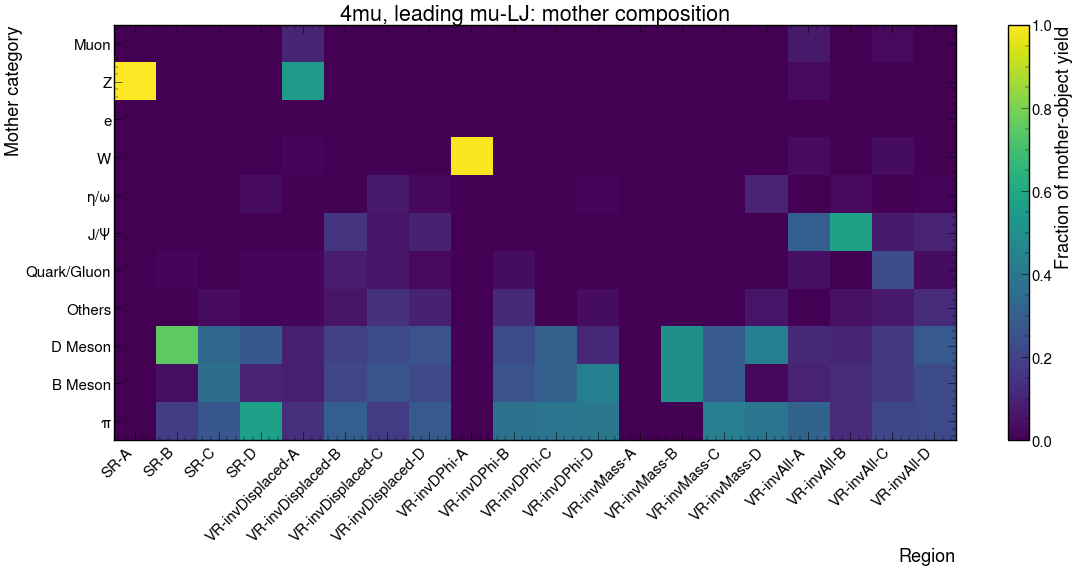

### 4mu, subleading mu-LJ: mother-object yield

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.0000,3.2480,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
SR-B,0.0000,0.0000,0.0,0.0000,0.0026,0.0000,0.0119,0.0026,1.4101,1.3809,0.1536
SR-C,0.0000,0.0000,0.0,0.0000,0.0180,0.0000,0.0326,0.0752,0.4432,1.4599,6.5638
SR-D,0.0000,0.0000,0.0,0.0000,11.1439,0.0000,15.5212,4.4079,22.4472,4.8508,75.5189
VR-invDisplaced-A,32.5060,123.1688,0.0,3.2737,0.0000,0.0000,3.4352,3.9524,25.2765,18.7945,10.4242
VR-invDisplaced-B,0.0000,3.2480,0.0,0.0000,7.5586,0.3862,17.4911,4.2755,103.8576,122.2434,80.8139
VR-invDisplaced-C,6.4961,9.9409,0.0,3.2737,386.7661,35.8709,8.2248,177.5309,975.4303,1100.2000,1954.2695
VR-invDisplaced-D,4.0319,0.0000,0.0,13.0946,222.2052,181.9232,275.4262,812.8665,4079.4152,3824.9077,3484.0940
VR-invDPhi-A,3.2737,0.0000,0.0,3.2737,0.0000,0.0000,0.0000,0.0051,0.0000,0.0051,0.0103


### 4mu, subleading mu-LJ: mother composition (%)

,Muon,Z,e,W,$\eta$/$\omega$,J/$\Psi$,Quark/Gluon,Others,D Meson,B Meson,$\pi$
region,,,,,,,,,,,
SR-A,0.00,100.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
SR-B,0.00,0.00,0.0,0.00,0.09,0.00,0.40,0.09,47.61,46.63,5.19
SR-C,0.00,0.00,0.0,0.00,0.21,0.00,0.38,0.87,5.16,16.99,76.39
SR-D,0.00,0.00,0.0,0.00,8.32,0.00,11.59,3.29,16.77,3.62,56.40
VR-invDisplaced-A,14.72,55.78,0.0,1.48,0.00,0.00,1.56,1.79,11.45,8.51,4.72
VR-invDisplaced-B,0.00,0.96,0.0,0.00,2.22,0.11,5.15,1.26,30.56,35.97,23.78
VR-invDisplaced-C,0.14,0.21,0.0,0.07,8.30,0.77,0.18,3.81,20.94,23.62,41.96
VR-invDisplaced-D,0.03,0.00,0.0,0.10,1.72,1.41,2.14,6.30,31.63,29.66,27.01
VR-invDPhi-A,49.84,0.00,0.0,49.84,0.00,0.00,0.00,0.08,0.00,0.08,0.16


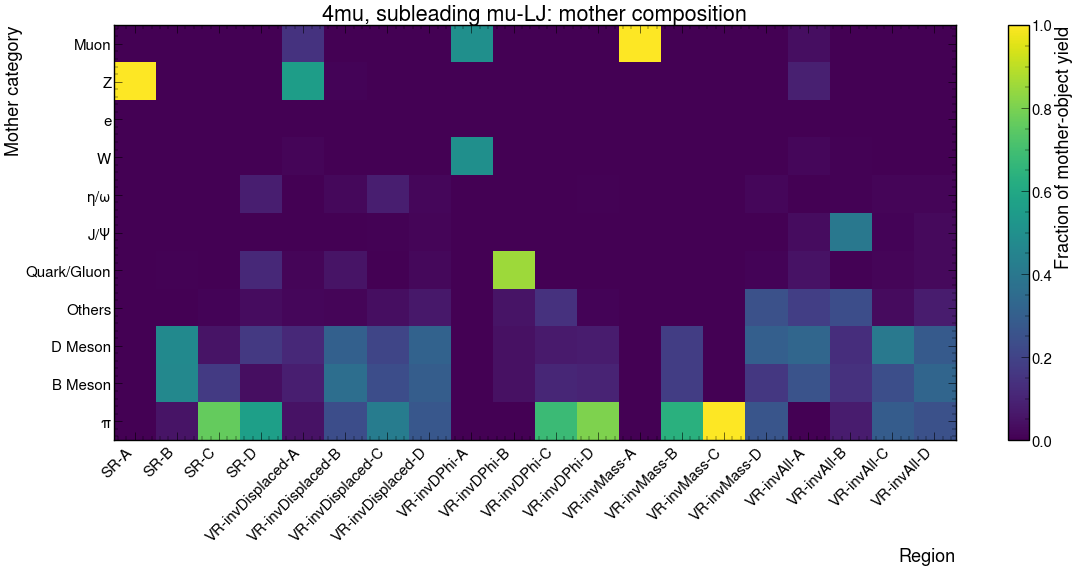

In [10]:
mother_yields = {}
mother_errors = {}
mother_fractions = {}

# First pass: build every yield table before choosing one global stack order.
for topology, config in TOPOLOGY_CONFIG.items():
    mother_yields[topology] = {}
    mother_errors[topology] = {}
    mother_fractions[topology] = {}
    for role in config["roles"]:
        yield_rows = []
        variance_rows = []
        for selection in SELECTIONS:
            for region in ABCD_REGIONS:
                label = f"{selection}-{region}"
                category_yields = defaultdict(float)
                category_variances = defaultdict(float)
                for sample in SAMPLES:
                    histogram = mother_histogram(sample, topology, role, selection, region)
                    sample_yields, sample_variances = categorize_mother_histogram(histogram)
                    for category in MOTHER_CATEGORY_ORDER:
                        category_yields[category] += sample_yields[category]
                        category_variances[category] += sample_variances[category]
                yield_rows.append({"region": label, **category_yields})
                variance_rows.append({"region": label, **category_variances})

        yield_table = pd.DataFrame(yield_rows).set_index("region").reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
        variance_table = pd.DataFrame(variance_rows).set_index("region").reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
        mother_yields[topology][role] = yield_table
        mother_errors[topology][role] = np.sqrt(variance_table)

# Use one common bottom-to-top order: lowest global yield first.
global_mother_yield = pd.Series(0.0, index=MOTHER_CATEGORY_ORDER)
for topology_tables in mother_yields.values():
    for yield_table in topology_tables.values():
        global_mother_yield = global_mother_yield.add(yield_table.sum(axis=0), fill_value=0.0)
MOTHER_STACK_ORDER = global_mother_yield.sort_values(kind="stable").index.tolist()

display(Markdown("### Common mother stack order (bottom → top)"))
display(global_mother_yield.reindex(MOTHER_STACK_ORDER).rename("global mother-object yield").to_frame())

# Second pass: use the same order in every yield stack and composition heatmap.
for topology, config in TOPOLOGY_CONFIG.items():
    for role in config["roles"]:
        yield_table = mother_yields[topology][role].reindex(columns=MOTHER_STACK_ORDER)
        error_table = mother_errors[topology][role].reindex(columns=MOTHER_STACK_ORDER)
        fraction_table = safe_fractions(yield_table)
        mother_yields[topology][role] = yield_table
        mother_errors[topology][role] = error_table
        mother_fractions[topology][role] = fraction_table

        display(Markdown(f"### {topology}, {role}: mother-object yield"))
        display(yield_table.round(4))
        display(Markdown(f"### {topology}, {role}: mother composition (%)"))
        display((100 * fraction_table).round(2))
        plot_fraction_heatmap(
            fraction_table,
            f"{topology}, {role}: mother composition",
        )

## Mother yield resolved by background source

The nested tables below retain the full `(background group, mother category)` breakdown for every topology, LJ role, and region.

In [11]:
mother_yields_by_source = {}

for topology, config in TOPOLOGY_CONFIG.items():
    mother_yields_by_source[topology] = {}
    for role in config["roles"]:
        rows = []
        for selection in SELECTIONS:
            for region in ABCD_REGIONS:
                label = f"{selection}-{region}"
                row = {"region": label}
                for group, samples in BACKGROUND_GROUPS.items():
                    grouped_yields = defaultdict(float)
                    for sample in samples:
                        histogram = mother_histogram(sample, topology, role, selection, region)
                        sample_yields, _ = categorize_mother_histogram(histogram)
                        for category in MOTHER_CATEGORY_ORDER:
                            grouped_yields[category] += sample_yields[category]
                    for category in MOTHER_CATEGORY_ORDER:
                        row[(group, category)] = grouped_yields[category]
                rows.append(row)

        table = pd.DataFrame(rows).set_index("region")
        table.columns = pd.MultiIndex.from_tuples(table.columns, names=["background", "mother"])
        mother_yields_by_source[topology][role] = table
        display(Markdown(f"### {topology}, {role}: background × mother yield"))
        display(table.round(4))

### 2mu2e, mu-LJ: background × mother yield

background         Diboson                                                  \
mother                   Z       W       e    Muon   $\pi$ $\eta$/$\omega$   
region                                                                       
SR-A                0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
SR-B                0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
SR-C                0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
SR-D                0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invDisplaced-A  11.2380  0.0000  0.1968  3.6314  0.0000             0.0   
VR-invDisplaced-B   0.5903  0.2067  0.0000  0.1968  1.6438             0.0   
VR-invDisplaced-C   3.4048  0.2067  0.0000  1.2005  0.0000             0.0   
VR-invDisplaced-D   0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invDPhi-A        0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invDPhi-B        0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invDPhi-C        0.3935  0.0000  0.0000  0.1968  0.0000             0.0   
VR-invDPhi-D        0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invMass-A        0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invMass-B        0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invMass-C        0.2067  0.2067  0.0000  0.2067  0.0000             0.0   
VR-invMass-D        0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invAll-A         2.2043  0.0000  0.0000  0.4134  0.4134             0.0   
VR-invAll-B         0.0000  0.0000  0.0000  0.0000  0.0000             0.0   
VR-invAll-C         1.5941  0.6201  0.0000  1.1906  0.0000             0.0   
VR-invAll-D         0.0000  0.0000  0.0000  0.0000  0.0000             0.0   

background                                                       TT            \
mother            B Meson D Meson Quark/Gluon J/$\Psi$  Others    Z         W   
region                                                                          
SR-A               0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
SR-B               0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
SR-C               0.0000  0.0000         0.0   0.0000  0.0000  0.0    3.2737   
SR-D               0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invDisplaced-A  0.2067  0.4028         0.0   0.4134  1.4470  0.0   36.0102   
VR-invDisplaced-B  0.4134  0.8070         0.0   0.8070  0.8268  0.0  108.0306   
VR-invDisplaced-C  0.4028  0.8056         0.0   0.0000  0.0000  0.0   26.1892   
VR-invDisplaced-D  0.4134  0.4134         0.0   0.0000  0.0000  0.0  101.4833   
VR-invDPhi-A       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invDPhi-B       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invDPhi-C       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invDPhi-D       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invMass-A       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invMass-B       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invMass-C       0.0000  0.0000         0.0   0.0000  0.0000  0.0    3.2737   
VR-invMass-D       0.0000  0.0000         0.0   0.0000  0.0000  0.0    0.0000   
VR-invAll-A        0.0000  0.0000         0.0   0.0000  0.3935  0.0   13.0946   
VR-invAll-B        0.0000  0.0000         0.0   0.0000  0.0000  0.0   32.7365   
VR-invAll-C        0.0000  0.0000         0.0   0.0000  0.6201  0.0   75.2941   
VR-invAll-D        0.0000  0.0000         0.0   0.0000  0.0000  0.0   36.0102   

background                                                              \
mother                  e     Muon     $\pi$ $\eta$/$\omega$   B Meson   
region                                                                   
SR-A               0.0000   0.0000    0.0000          0.0000    0.0000   
SR-B               0.0000   0.0000    0.0000 

### 2mu2e, egm-LJ: background × mother yield

background        Diboson                                                  \
mother                  Z       W       e    Muon   $\pi$ $\eta$/$\omega$   
region                                                                      
SR-A               0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
SR-B               0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
SR-C               0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
SR-D               0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invDisplaced-A  3.3452  4.9398  4.2011  0.0000  0.0000          0.0000   
VR-invDisplaced-B  0.9938  0.4134  0.9938  0.0000  0.2067          0.2067   
VR-invDisplaced-C  0.5903  1.2297  1.2098  0.0000  1.0037          0.0000   
VR-invDisplaced-D  0.0000  0.6095  0.8162  0.0000  0.0000          0.0000   
VR-invDPhi-A       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invDPhi-B       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invDPhi-C       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invDPhi-D       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invMass-A       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invMass-B       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invMass-C       0.0000  0.0000  0.0000  0.2067  0.0000          0.0000   
VR-invMass-D       0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invAll-A        1.1906  0.8162  1.1998  0.4134  0.4134          0.0000   
VR-invAll-B        0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   
VR-invAll-C        0.9839  0.4134  0.7970  0.4134  0.0000          0.0000   
VR-invAll-D        0.0000  0.0000  0.0000  0.0000  0.0000          0.0000   

background                                                       TT            \
mother            B Meson D Meson Quark/Gluon J/$\Psi$  Others    Z         W   
region                                                                          
SR-A               0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
SR-B               0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
SR-C               0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
SR-D               0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invDisplaced-A  0.0000     0.0      0.0000      0.0  1.8008  0.0   68.7468   
VR-invDisplaced-B  0.0000     0.0      0.0000      0.0  0.0000  0.0  405.9332   
VR-invDisplaced-C  0.3935     0.0      0.5903      0.0  0.0000  0.0   22.9156   
VR-invDisplaced-D  0.0000     0.0      0.0000      0.0  0.0000  0.0  121.1252   
VR-invDPhi-A       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invDPhi-B       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invDPhi-C       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invDPhi-D       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invMass-A       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invMass-B       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invMass-C       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invMass-D       0.0000     0.0      0.0000      0.0  0.0000  0.0    0.0000   
VR-invAll-A        0.0000     0.0      0.0000      0.0  1.1806  0.0   58.9258   
VR-invAll-B        0.0000     0.0      0.0000      0.0  0.0000  0.0  409.2068   
VR-invAll-C        0.0000     0.0      0.0000      0.0  0.6201  0.0   52.3785   
VR-invAll-D        0.0000     0.0      0.0000      0.0  0.0000  0.0  225.8822   

background                                                                     \
mother                    e Muon     $\pi$ $\eta$/$\omega$   B Meson  D Meson   
region                                                                          
SR-A                 0.0000  0.0    0.0000          0.0000    0.0000   0.0000   
SR-B                 0.0000  0.0    0.00

### 4mu, leading mu-LJ: background × mother yield

background        Diboson                                                     \
mother                  Z       W    e    Muon $\pi$ $\eta$/$\omega$ B Meson   
region                                                                         
SR-A               0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
SR-B               0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
SR-C               0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
SR-D               0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invDisplaced-A  3.1782  0.4134  0.0  1.0037   0.0             0.0  0.0000   
VR-invDisplaced-B  0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invDisplaced-C  0.7871  0.0000  0.0  0.1968   0.0             0.0  0.0000   
VR-invDisplaced-D  0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invDPhi-A       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invDPhi-B       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invDPhi-C       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invDPhi-D       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invMass-A       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invMass-B       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invMass-C       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invMass-D       0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invAll-A        0.4134  0.0000  0.0  0.2067   0.0             0.0  0.0000   
VR-invAll-B        0.0000  0.0000  0.0  0.0000   0.0             0.0  0.0000   
VR-invAll-C        0.0000  0.8268  0.0  0.0000   0.0             0.0  0.4134   
VR-invAll-D        0.0000  0.0000  0.0  0.0000   0.0             0.0  0.8268   

background                                              TT                \
mother            D Meson Quark/Gluon J/$\Psi$ Others    Z        W    e   
region                                                                     
SR-A               0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
SR-B               0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
SR-C               0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
SR-D               0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invDisplaced-A  0.0000         0.0      0.0    0.0  0.0   3.2737  0.0   
VR-invDisplaced-B  0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invDisplaced-C  0.0000         0.0      0.0    0.0  0.0  19.6419  0.0   
VR-invDisplaced-D  0.0000         0.0      0.0    0.0  0.0  39.2839  0.0   
VR-invDPhi-A       0.0000         0.0      0.0    0.0  0.0   3.2737  0.0   
VR-invDPhi-B       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invDPhi-C       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invDPhi-D       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invMass-A       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invMass-B       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invMass-C       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invMass-D       0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invAll-A        0.0000         0.0      0.0    0.0  0.0  13.0946  0.0   
VR-invAll-B        0.0000         0.0      0.0    0.0  0.0   0.0000  0.0   
VR-invAll-C        0.4134         0.0      0.0    0.0  0.0  22.9156  0.0   
VR-invAll-D        0.4134         0.0      0.0    0.0  0.0   3.2737  0.0   

background                                                             \
mother                Muon    $\pi$ $\eta$/$\omega$  B Meson  D Meson   
region                                                                  
SR-A                0.0000   0.0000          0.0000   0.0000   0.0000   
SR-B                0.0000   0.0000          0.0000   0.0000   0.0000   
SR-C                0.0000   0.0000          

### 4mu, subleading mu-LJ: background × mother yield

background        Diboson                                               \
mother                  Z       W    e    Muon   $\pi$ $\eta$/$\omega$   
region                                                                   
SR-A               0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
SR-B               0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
SR-C               0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
SR-D               0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDisplaced-A  2.9914  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDisplaced-B  0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDisplaced-C  0.1968  0.0000  0.0  0.0000  1.1806          0.3935   
VR-invDisplaced-D  0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDPhi-A       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDPhi-B       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDPhi-C       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invDPhi-D       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invMass-A       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invMass-B       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invMass-C       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invMass-D       0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invAll-A        0.4134  0.0000  0.0  0.6201  0.0000          0.0000   
VR-invAll-B        0.0000  0.0000  0.0  0.0000  0.0000          0.0000   
VR-invAll-C        0.0000  0.2067  0.0  0.0000  0.0000          0.0000   
VR-invAll-D        0.0000  0.0000  0.0  0.0000  0.0000          0.0000   

background                                                      TT           \
mother            B Meson D Meson Quark/Gluon J/$\Psi$ Others    Z        W   
region                                                                        
SR-A               0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
SR-B               0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
SR-C               0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
SR-D               0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invDisplaced-A  0.0000  0.0000         0.0      0.0    0.0  0.0   3.2737   
VR-invDisplaced-B  0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invDisplaced-C  0.0000  0.3935         0.0      0.0    0.0  0.0   3.2737   
VR-invDisplaced-D  0.0000  0.0000         0.0      0.0    0.0  0.0  13.0946   
VR-invDPhi-A       0.0000  0.0000         0.0      0.0    0.0  0.0   3.2737   
VR-invDPhi-B       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invDPhi-C       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invDPhi-D       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invMass-A       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invMass-B       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invMass-C       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invMass-D       0.0000  0.0000         0.0      0.0    0.0  0.0   0.0000   
VR-invAll-A        0.0000  0.0000         0.0      0.0    0.0  0.0   3.2737   
VR-invAll-B        0.0000  0.0000         0.0      0.0    0.0  0.0   3.2737   
VR-invAll-C        0.8268  0.8268         0.0      0.0    0.0  0.0   0.0000   
VR-invAll-D        0.8268  0.8268         0.0      0.0    0.0  0.0   3.2737   

background                                                                 \
mother               e    Muon    $\pi$ $\eta$/$\omega$  B Meson  D Meson   
region                                                                      
SR-A               0.0  0.0000   0.0000          0.0000   0.0000   0.0000   
SR-B               0.0  0.0000   0.0000          0.0000   0.0000   0.0000   
SR-C               0.0  0.0000   0.0000          0.0000   0.0000   0.0000   
SR-D             

## Process-resolved mother yield with signal-like/background-like ratios

This is the direct ABCD analogue of the process overlay in notebook `02`. For each configured SR/VR selection and LJ role, the bar is the inclusive mother-object yield (`A+B+C+D`), while the red circle and blue cross show signal-like `A` and background-like `D`. The lower panel shows their ratios to inclusive. Error bars are propagated from histogram variances.

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


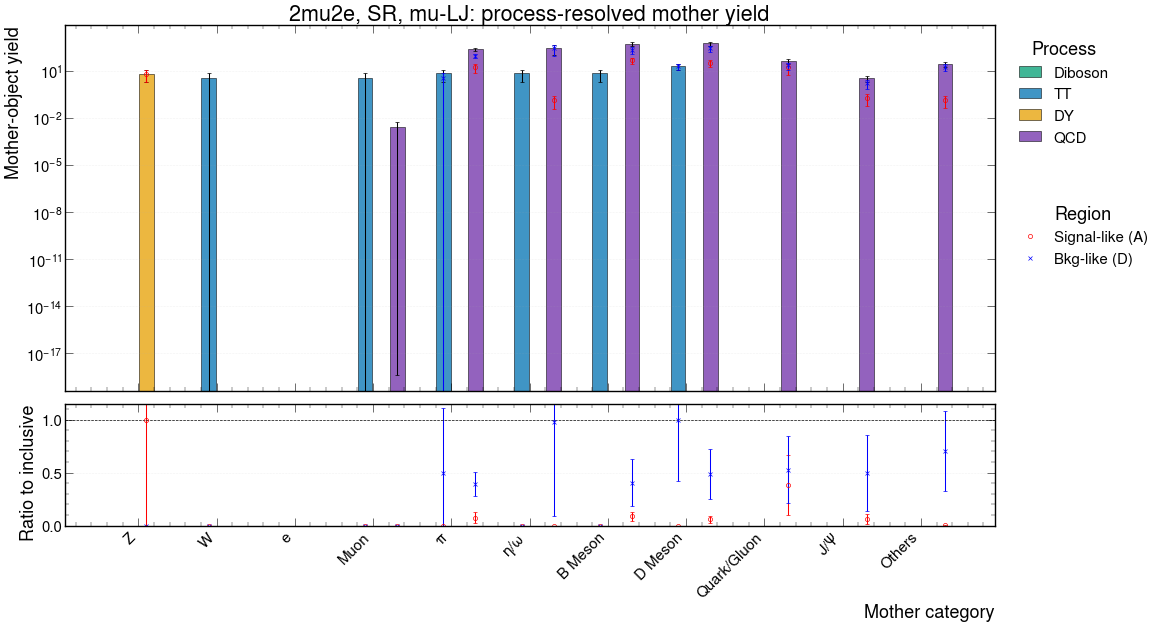

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


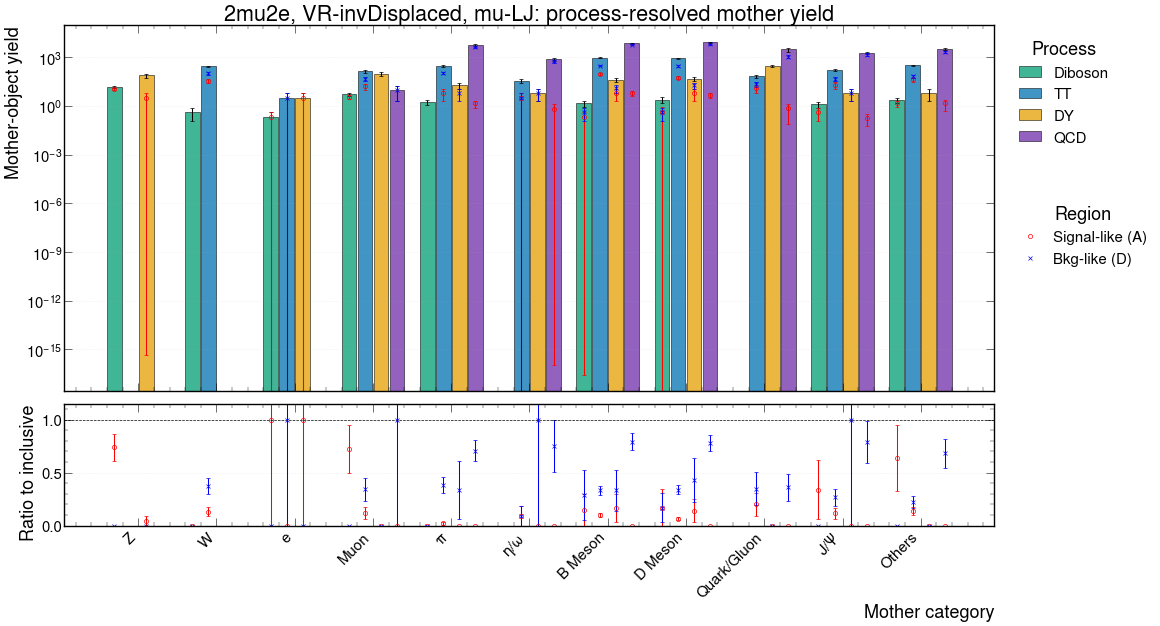

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


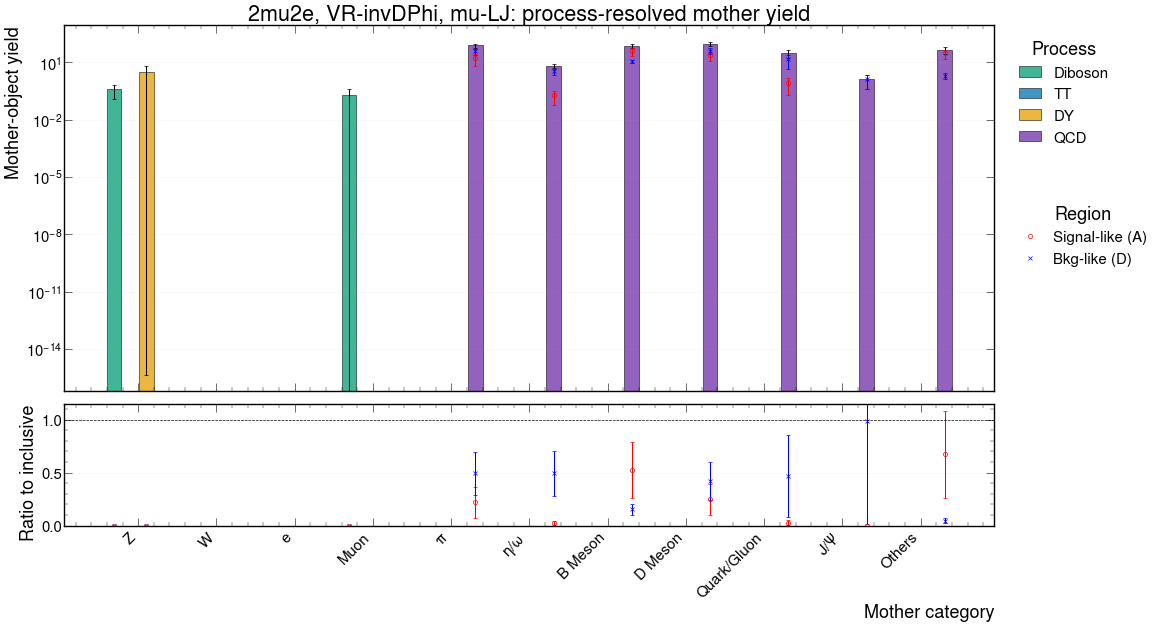

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


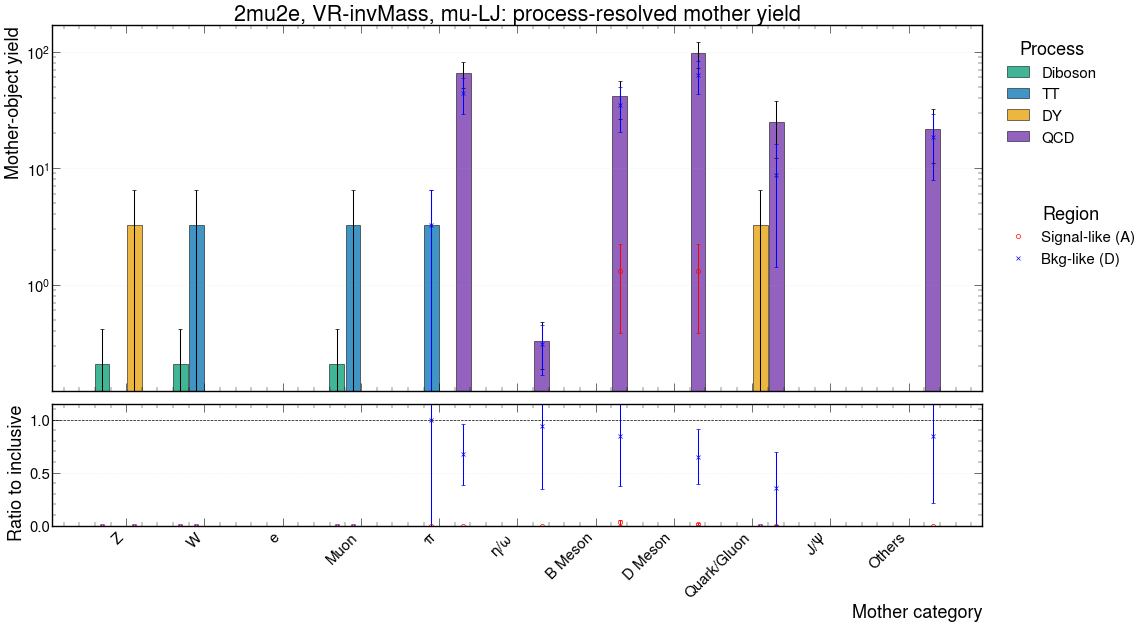

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


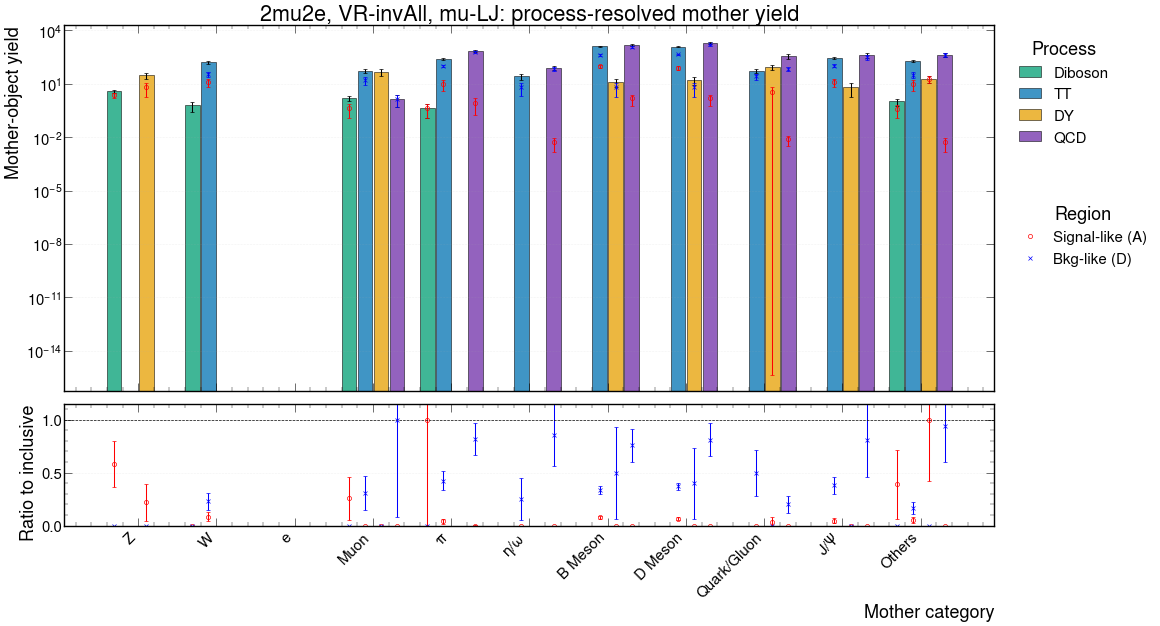

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


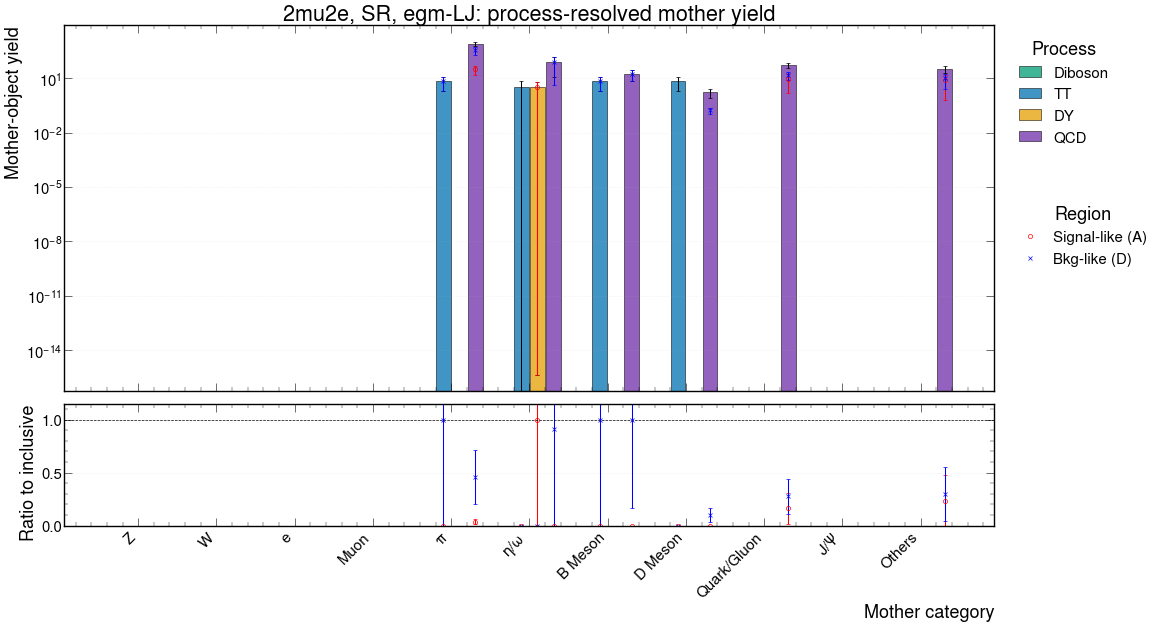

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


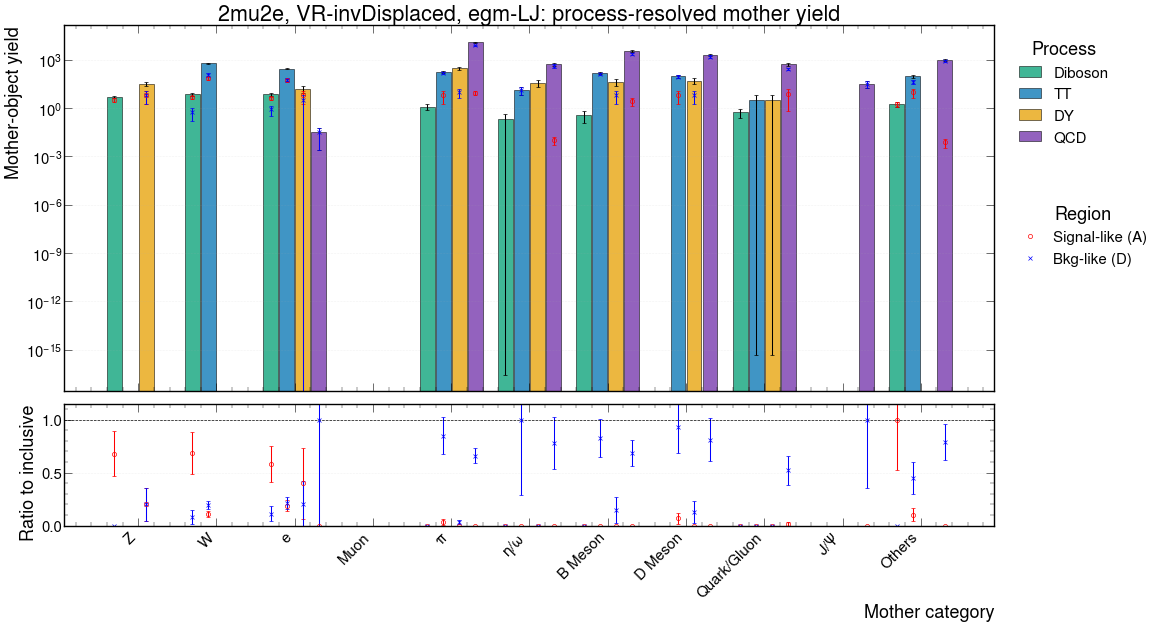

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


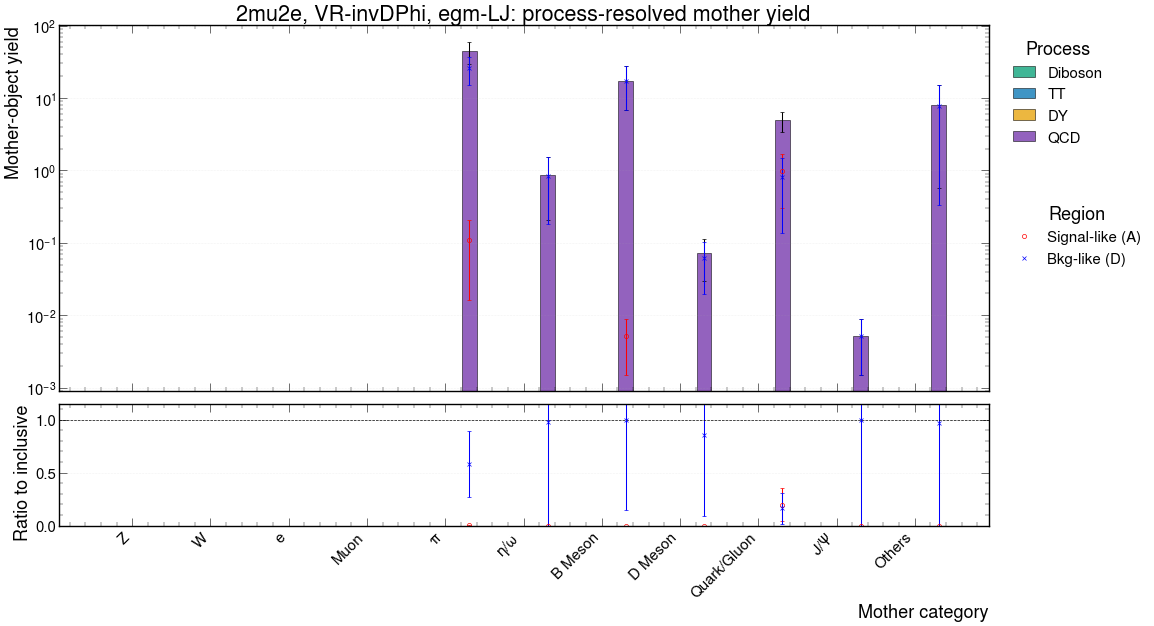

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


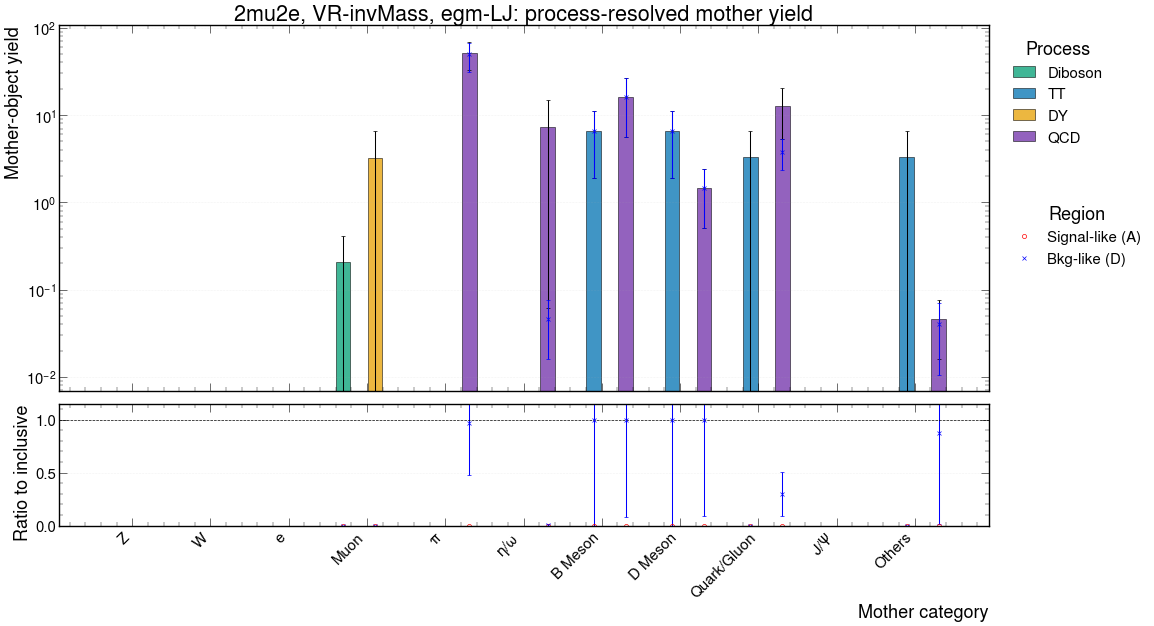

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


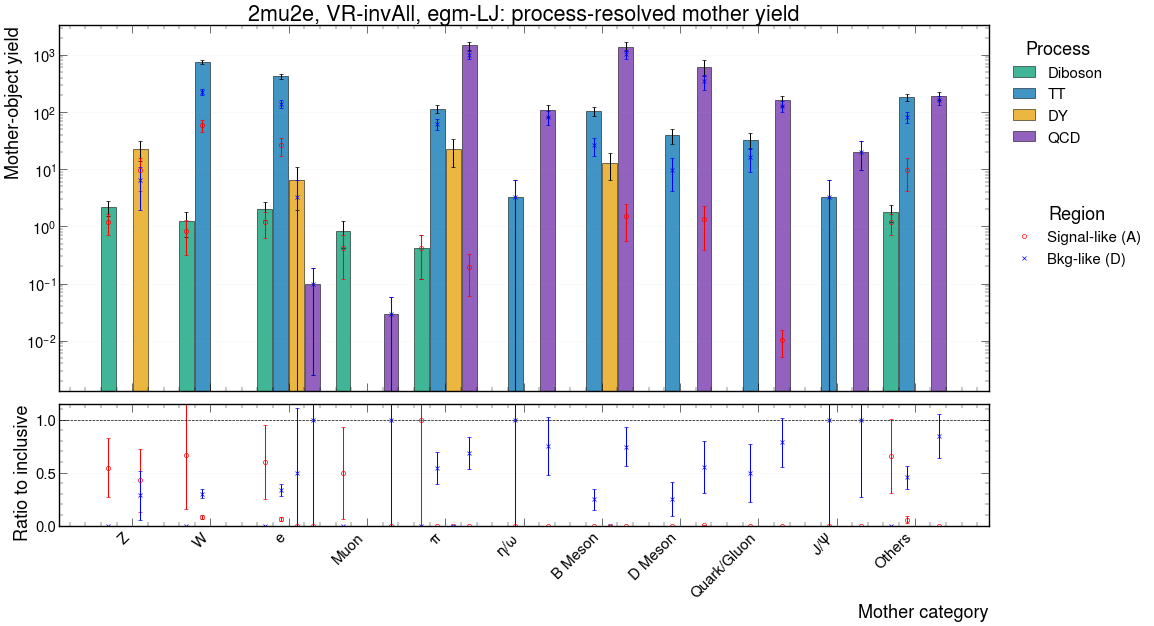

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


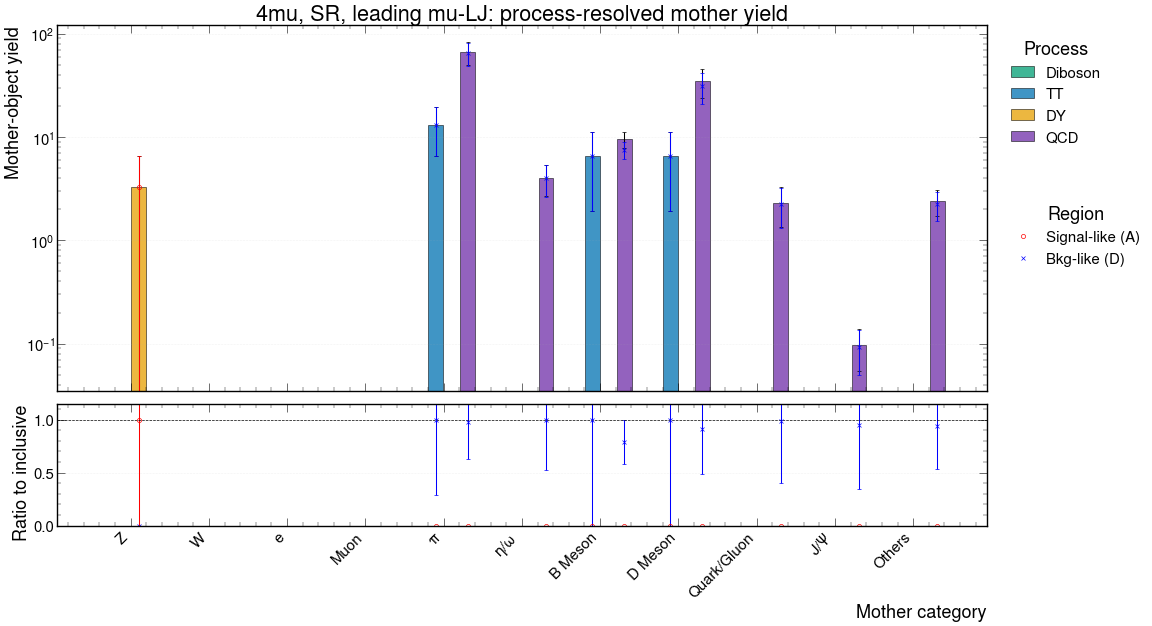

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


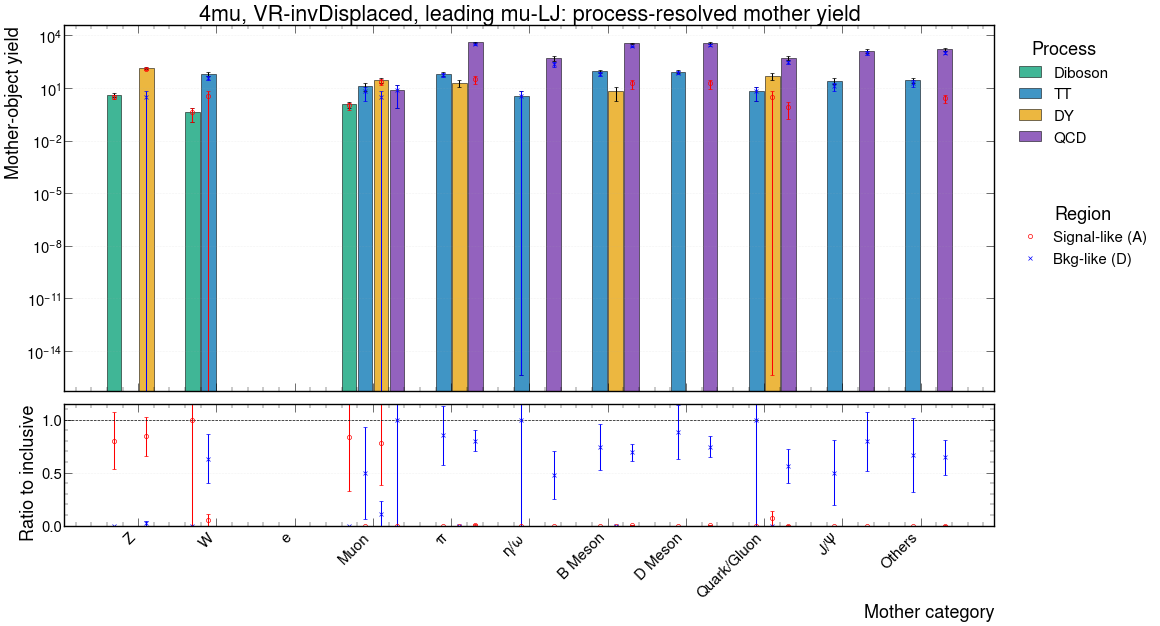

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


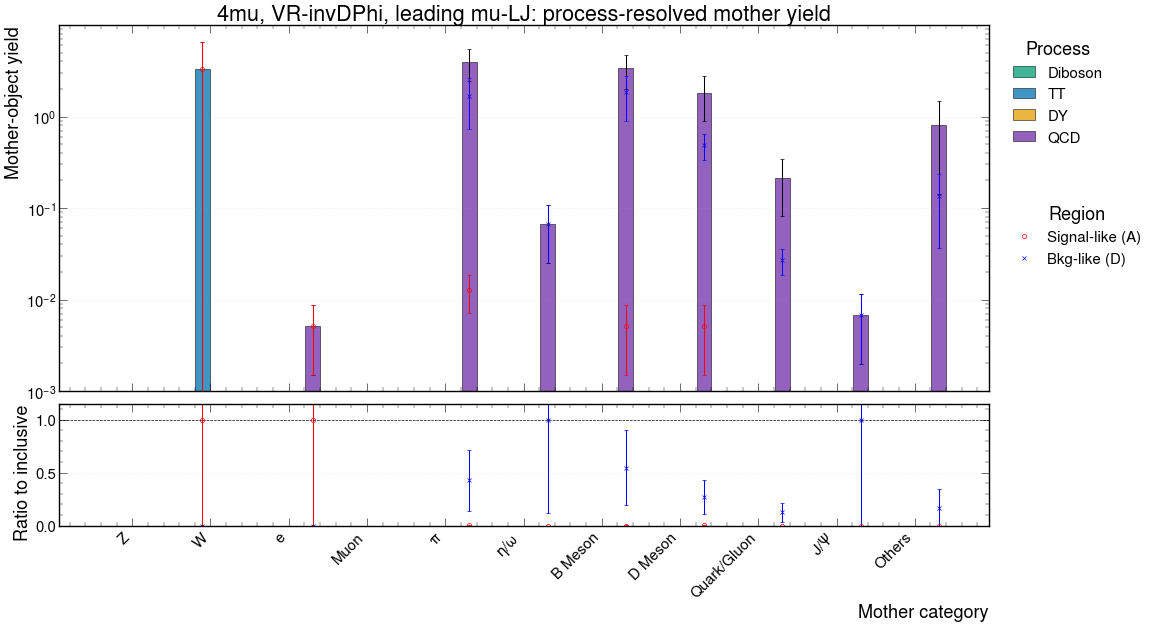

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


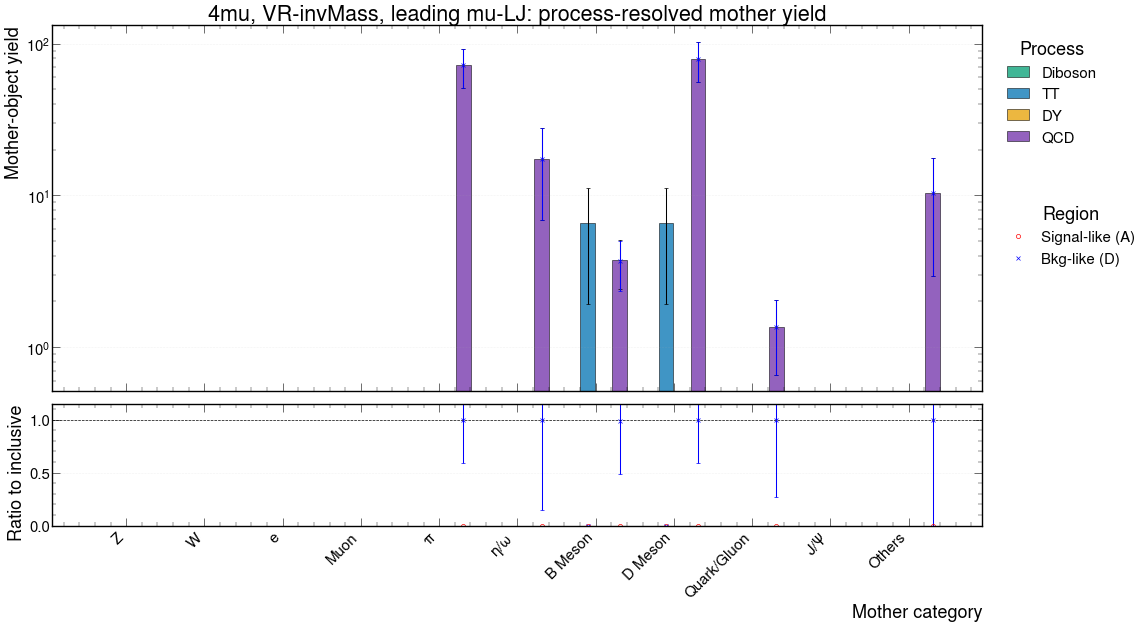

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


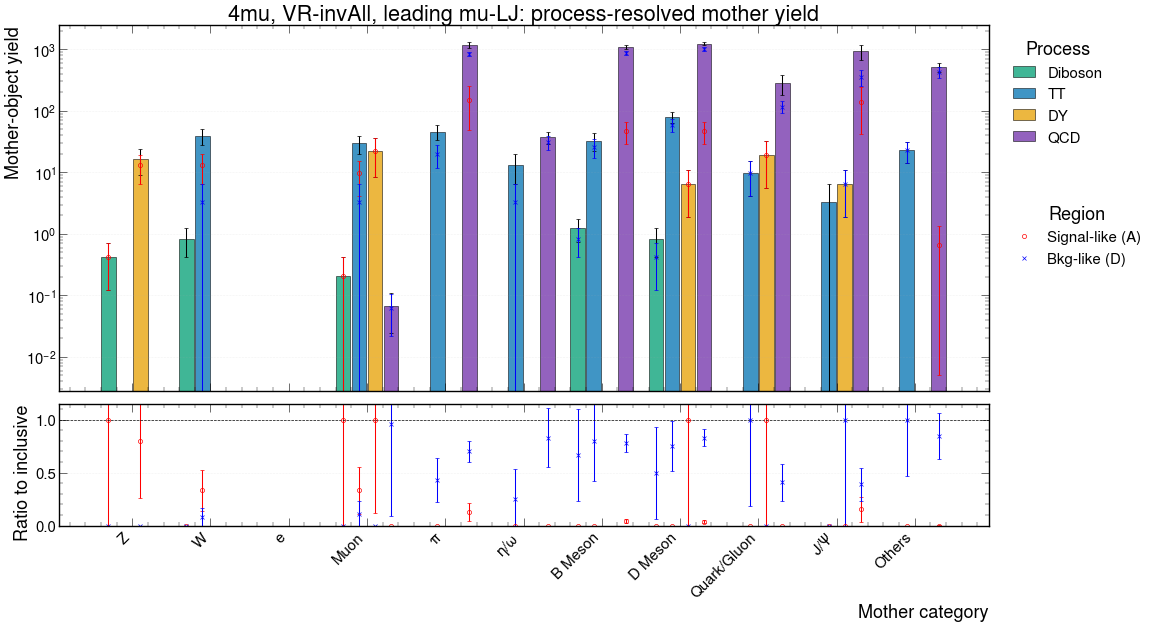

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


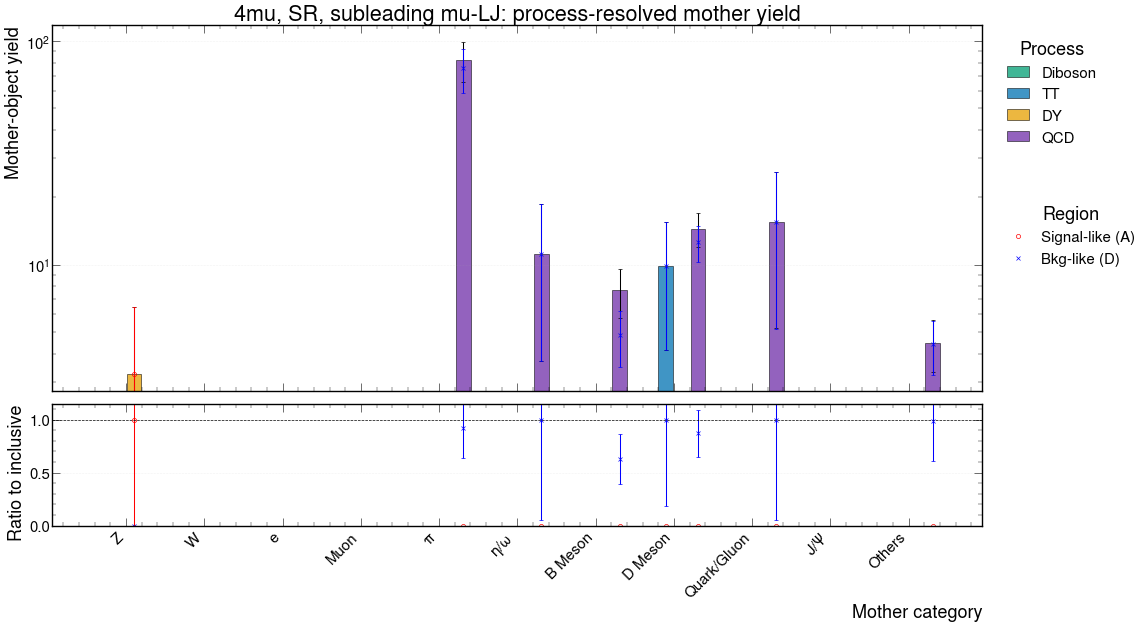

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


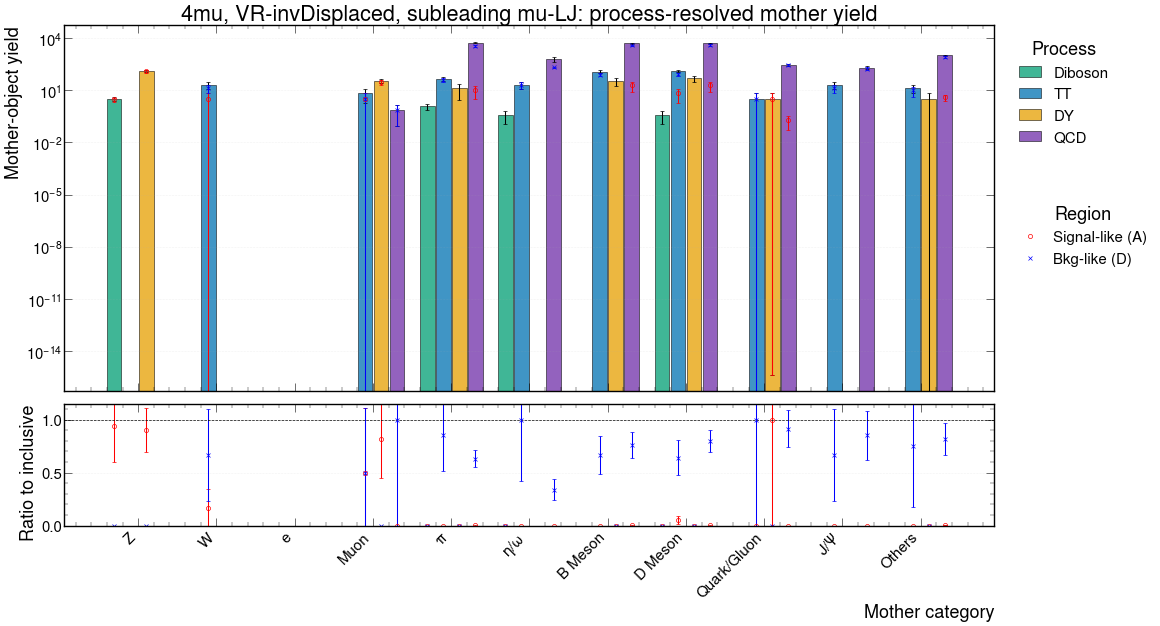

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


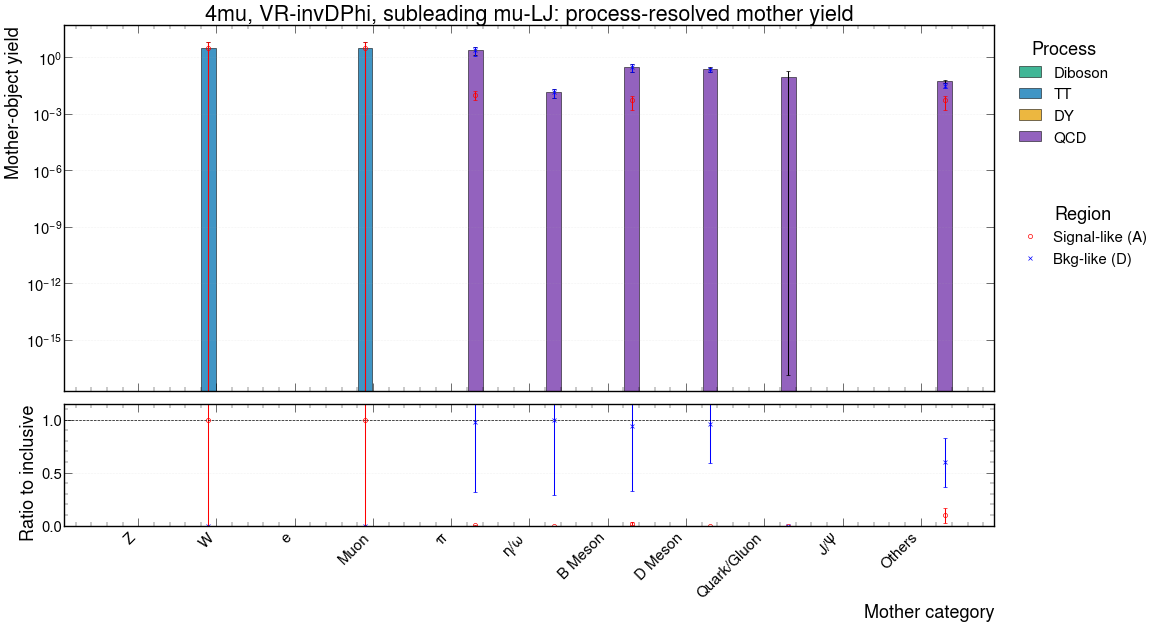

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


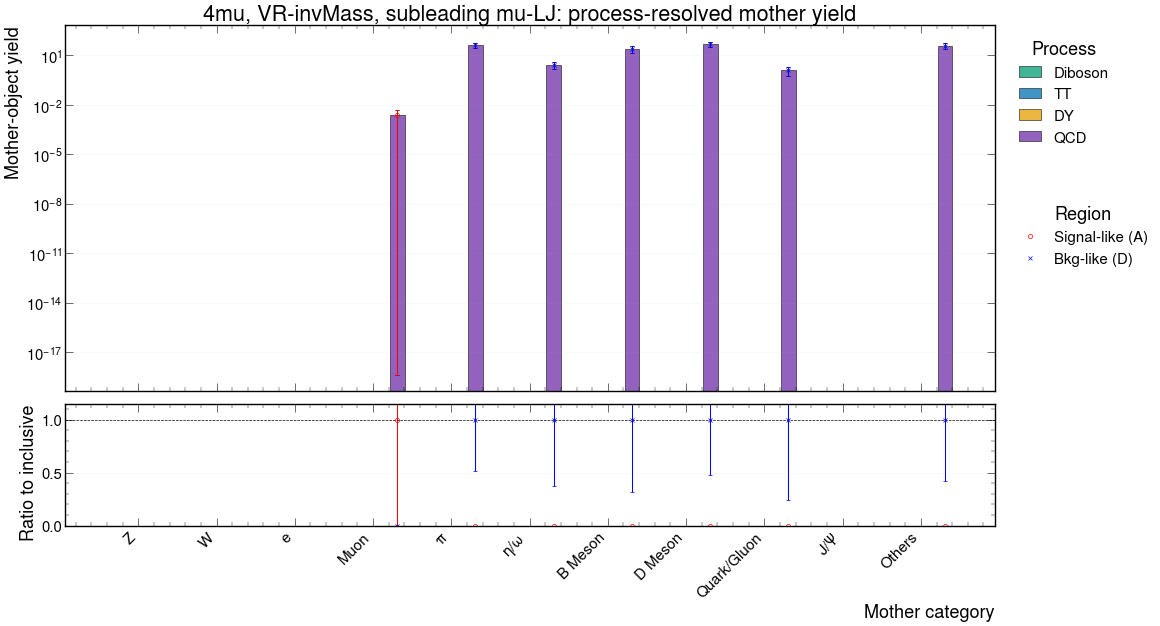

/tmp/ipykernel_2975/2262421356.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


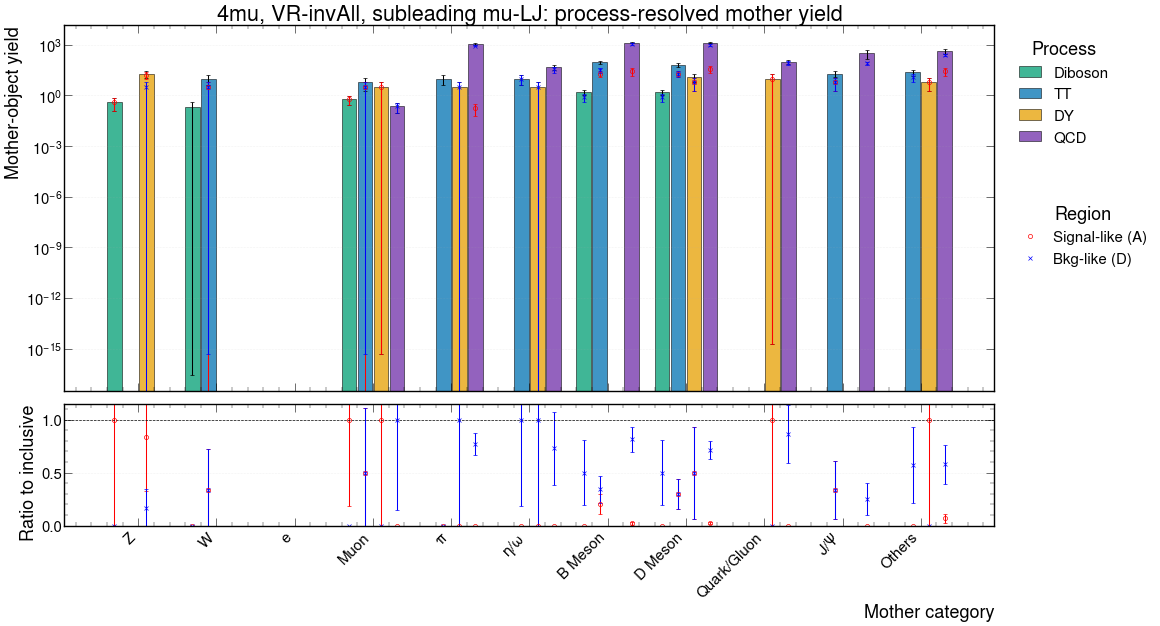

In [12]:
def process_mother_tables(topology, role, selection):
    region_yields = {}
    region_variances = {}
    for region in ABCD_REGIONS:
        yield_rows = {}
        variance_rows = {}
        for group, samples in BACKGROUND_GROUPS.items():
            grouped_yields = defaultdict(float)
            grouped_variances = defaultdict(float)
            for sample in samples:
                sample_yields, sample_variances = categorize_mother_histogram(
                    mother_histogram(sample, topology, role, selection, region)
                )
                for category in MOTHER_CATEGORY_ORDER:
                    grouped_yields[category] += sample_yields[category]
                    grouped_variances[category] += sample_variances[category]
            yield_rows[group] = grouped_yields
            variance_rows[group] = grouped_variances
        region_yields[region] = pd.DataFrame(yield_rows).T.reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
        region_variances[region] = pd.DataFrame(variance_rows).T.reindex(columns=MOTHER_CATEGORY_ORDER, fill_value=0.0)
    inclusive_yield = sum(region_yields.values())
    inclusive_variance = sum(region_variances.values())
    return {
        "Inclusive": inclusive_yield,
        "Signal-like": region_yields["A"],
        "Bkg-like": region_yields["D"],
        "_errors": {
            "Inclusive": np.sqrt(inclusive_variance),
            "Signal-like": np.sqrt(region_variances["A"]),
            "Bkg-like": np.sqrt(region_variances["D"]),
        },
    }


def plot_process_mother_overlay(tables, title):
    inclusive = tables["Inclusive"]
    signal = tables["Signal-like"]
    background = tables["Bkg-like"]
    errors = tables["_errors"]
    categories = list(inclusive.columns)
    processes = list(inclusive.index)
    x = np.arange(len(categories))
    width = 0.82 / len(processes)
    offsets = (np.arange(len(processes)) - (len(processes) - 1) / 2) * width
    fig, (ax, rax) = plt.subplots(2, 1, figsize=(24, 13), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})
    for index, process in enumerate(processes):
        positions = x + offsets[index]
        inc = inclusive.loc[process].to_numpy(float)
        inc_err = errors["Inclusive"].loc[process].to_numpy(float)
        sig = signal.loc[process].to_numpy(float)
        sig_err = errors["Signal-like"].loc[process].to_numpy(float)
        bkg = background.loc[process].to_numpy(float)
        bkg_err = errors["Bkg-like"].loc[process].to_numpy(float)
        ax.bar(positions, inc, width=0.92*width, color=GROUP_COLORS[process], edgecolor="black", alpha=0.75, label=process)
        mask = inc > 0
        ax.errorbar(positions[mask], inc[mask], yerr=inc_err[mask], fmt="none", ecolor="black", capsize=3)
        sig_mask = sig > 0
        bkg_mask = bkg > 0
        ax.errorbar(positions[sig_mask], sig[sig_mask], yerr=sig_err[sig_mask], marker="o", markerfacecolor="none",
                    markeredgecolor="red", ecolor="red", capsize=3, linestyle="none")
        ax.errorbar(positions[bkg_mask], bkg[bkg_mask], yerr=bkg_err[bkg_mask], marker="x",
                    color="blue", ecolor="blue", capsize=3, linestyle="none")
        sig_ratio, sig_ratio_error = ratio_uncertainty(sig, sig_err, inc, inc_err)
        bkg_ratio, bkg_ratio_error = ratio_uncertainty(bkg, bkg_err, inc, inc_err)
        for ratio, ratio_error, marker, color in (
            (sig_ratio, sig_ratio_error, "o", "red"), (bkg_ratio, bkg_ratio_error, "x", "blue")
        ):
            valid = np.isfinite(ratio)
            rax.errorbar(positions[valid], ratio[valid], yerr=ratio_error[valid], marker=marker,
                         markerfacecolor="none" if marker == "o" else color, color=color,
                         ecolor=color, capsize=3, linestyle="none")
    ax.set_yscale("log")
    ax.set(title=title, ylabel="Mother-object yield")
    ax.grid(axis="y", linestyle=":", alpha=0.3)
    from matplotlib.lines import Line2D
    process_legend = ax.legend(title="Process", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.add_artist(process_legend)
    ax.legend(handles=[
        Line2D([], [], marker="o", markerfacecolor="none", color="red", linestyle="none", label="Signal-like (A)"),
        Line2D([], [], marker="x", color="blue", linestyle="none", label="Bkg-like (D)"),
    ], title="Region", bbox_to_anchor=(1.01, 0.55), loc="upper left")
    rax.axhline(1, color="black", linestyle="--", linewidth=1)
    rax.set(ylabel="Ratio to inclusive", xlabel="Mother category", ylim=(0, 1.15))
    rax.set_xticks(x, categories, rotation=45, ha="right")
    rax.grid(axis="y", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

process_mother_overlay_tables = {}
for topology, config in TOPOLOGY_CONFIG.items():
    process_mother_overlay_tables[topology] = {}
    for role in config["roles"]:
        process_mother_overlay_tables[topology][role] = {}
        for selection in SELECTIONS:
            tables = process_mother_tables(topology, role, selection)
            process_mother_overlay_tables[topology][role][selection] = tables
            plot_process_mother_overlay(tables, f"{topology}, {selection}, {role}: process-resolved mother yield")

## Compact landing summary

For each region, report the total event yield, dominant background process, and dominant mother category for each LJ role.

In [13]:
summary_rows = []
for topology, config in TOPOLOGY_CONFIG.items():
    source_table = group_landing_yields[topology]
    for region_label in source_table.index:
        row = {
            "topology": topology,
            "region": region_label,
            "event_yield": source_table.loc[region_label].sum(),
            "dominant_background": source_table.loc[region_label].idxmax(),
        }
        for role in config["roles"]:
            composition = mother_yields[topology][role].loc[region_label]
            row[f"{role}: mother_yield"] = composition.sum()
            row[f"{role}: dominant_mother"] = composition.idxmax() if composition.sum() != 0 else "empty"
        summary_rows.append(row)

landing_summary = pd.DataFrame(summary_rows).set_index(["topology", "region"])
display(landing_summary.round(4))

event_yield dominant_background  \
topology region                                               
2mu2e    SR-A                   30.3812                 QCD   
         SR-B                  111.7673                 QCD   
         SR-C                   30.8287                 QCD   
         SR-D                  253.0690                 QCD   
         VR-invDisplaced-A      99.3427                  TT   
         VR-invDisplaced-B     702.2940                  TT   
         VR-invDisplaced-C    2026.1348                 QCD   
         VR-invDisplaced-D    4615.7348                 QCD   
         VR-invDPhi-A           15.7540                 QCD   
         VR-invDPhi-B            8.0418                 QCD   
         VR-invDPhi-C           19.6146                 QCD   
         VR-invDPhi-D           22.5366                 QCD   
         VR-invMass-A            0.6587                 QCD   
         VR-invMass-B           19.1913                 QCD   
         VR-invMass-C            9.9816                  DY   
         VR-invMass-D           41.1610                 QCD   
         VR-invAll-A            74.9105                  TT   
         VR-invAll-B           447.4690                  TT   
         VR-invAll-C           582.8166                 QCD   
         VR-invAll-D          1308.3285                 QCD   
4mu      SR-A                    3.2506                  DY   
         SR-B                    0.7495                 QCD   
         SR-C                    1.6717                 QCD   
         SR-D                   28.5739                 QCD   
         VR-invDisplaced-A     139.0847                  DY   
         VR-invDisplaced-B      84.7014                 QCD   
         VR-invDisplaced-C     999.8510                 QCD   
         VR-invDisplaced-D    2831.9386                 QCD   
         VR-invDPhi-A            3.2788                  TT   
         VR-invDPhi-B            0.8544                 QCD   
         VR-invDPhi-C            0.0085                 QCD   
         VR-invDPhi-D            0.9467                 QCD   
         VR-invMass-A            0.0026                 QCD   
         VR-invMass-B            3.2804                  TT   
         VR-invMass-C            0.0292                 QCD   
         VR-invMass-D           35.0335                 QCD   
         VR-invAll-A           129.4545                 QCD   
         VR-invAll-B           178.4849                 QCD   
         VR-invAll-C           200.2485                 QCD   
         VR-invAll-D           822.1708                 QCD   

                            mu-LJ: mother_yield mu-LJ: dominant_mother  \
topology region                                                          
2mu2e    SR-A                          117.5388                B Meson   
         SR-B                          524.2826                B Meson   
         SR-C                          144.2119                B Meson   
         SR-D                          882.1499                D Meson   
         VR-invDisplaced-A             336.6157                B Meson   
         VR-invDisplaced-B            3033.0185                D Meson   
         VR-invDisplaced-C            7726.0488            Quark/Gluon   
         VR-invDisplaced-D           22413.9352                D Meson   
         VR-invDPhi-A                  110.5791                B Meson   
         VR-invDPhi-B                   45.7172                D Meson   
         VR-invDPhi-C                   68.1195                B Meson   
         VR-invDPhi-D                  112.1203                D Meson   
         VR-invMass-A                    2.6349                D Meson   
         VR-invMass-B                   78.3174                D Meson   
         VR-invMass-C                   13.6661                   Muon   
         VR-invMass-D                  172.8704                D Meson   
         VR-invAll-A                   259.1669  

## LJ kinematics by inverted-cut channel and ABCD region

The plots below use the `pt`, `eta`, `phi`, and `mass` histograms stored in the same cosmic-veto ABCD background outputs. All background samples are summed. Each panel corresponds to one inverted-cut selection, and the four curves resolve the ABCD regions. Flow bins are included in the normalization and folded into the nearest visible edge bin for display.


### 2mu2e, mu-LJ

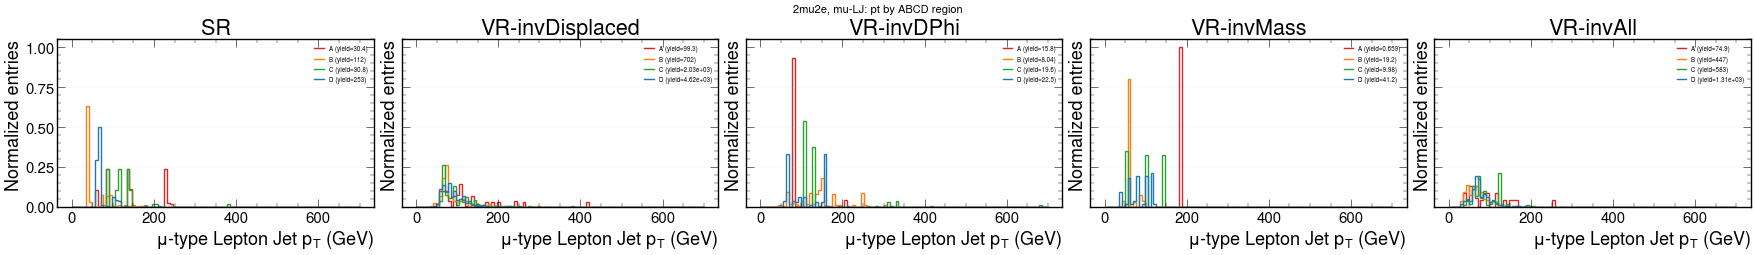

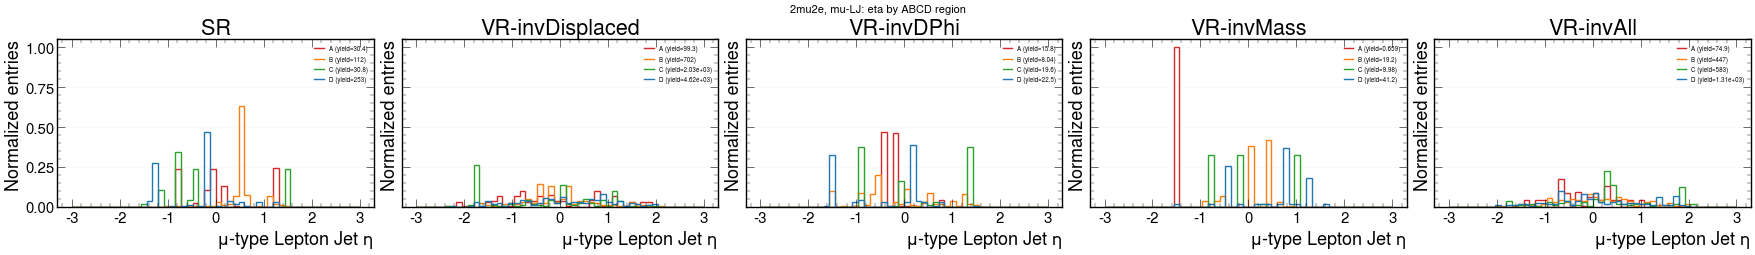

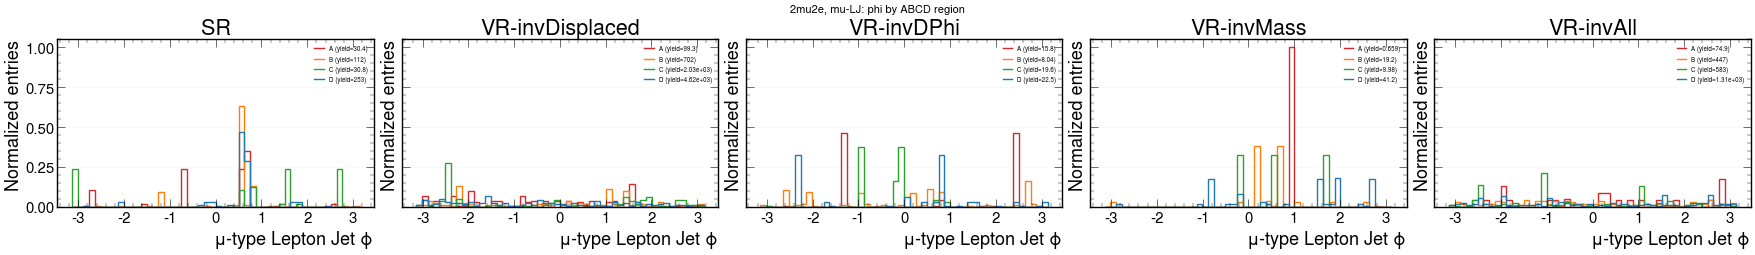

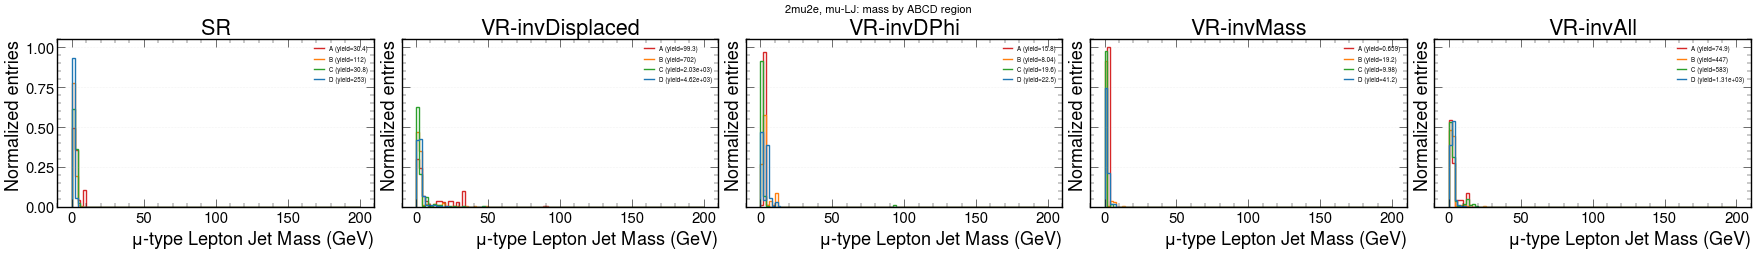

### 2mu2e, egm-LJ

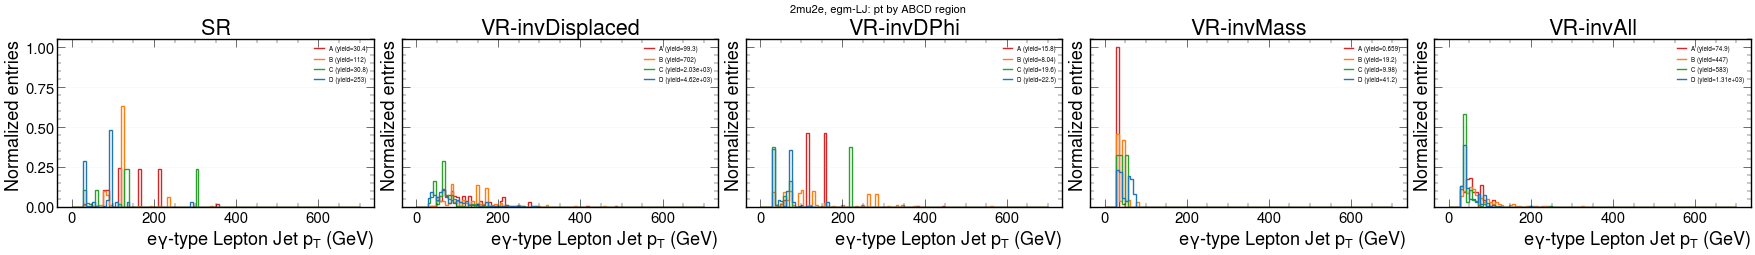

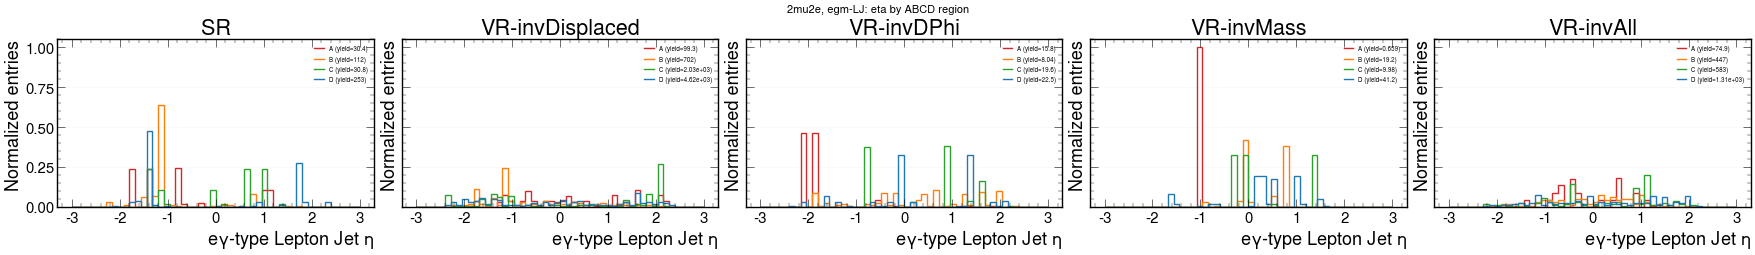

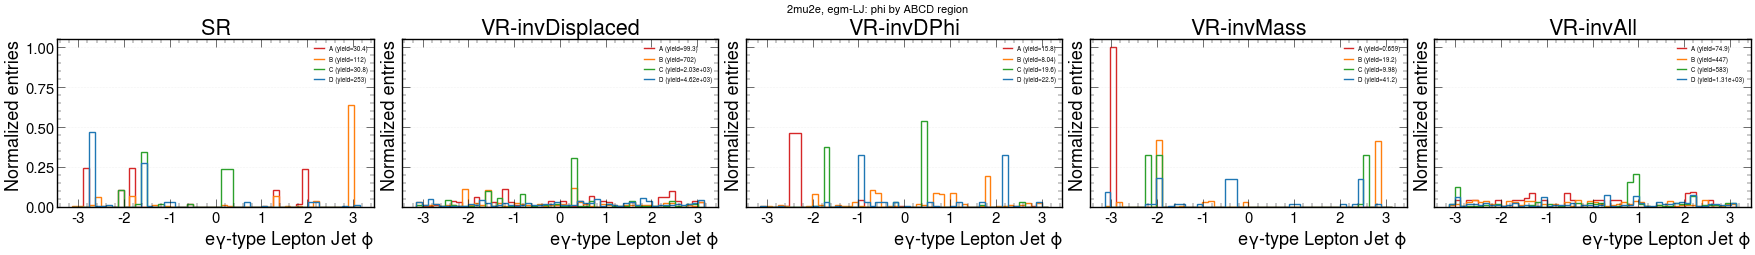

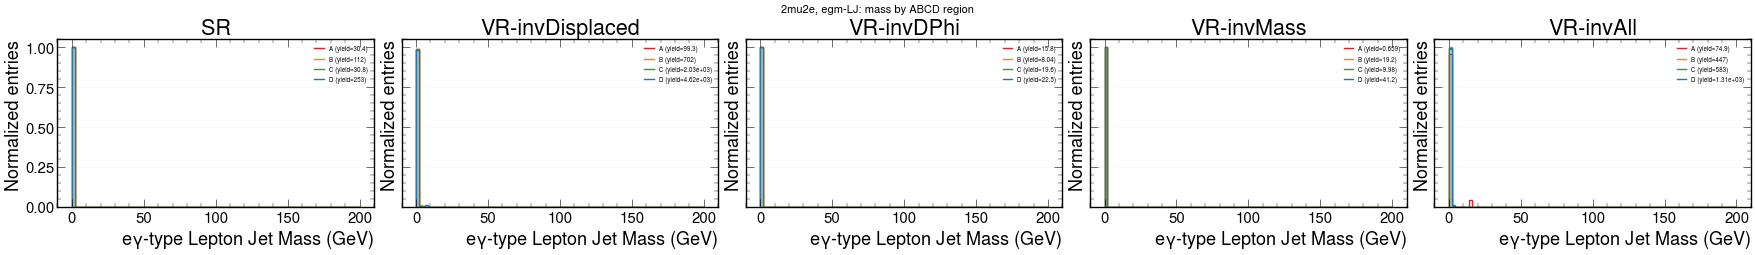

### 4mu, leading mu-LJ

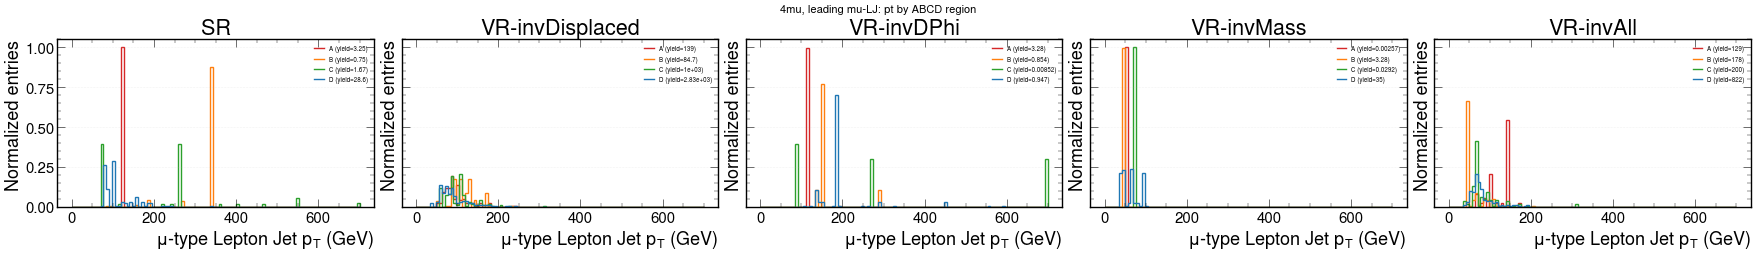

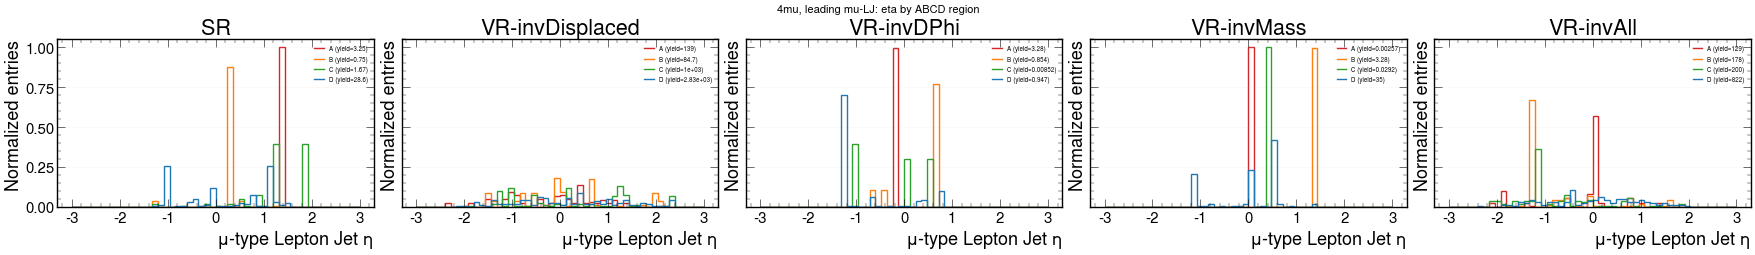

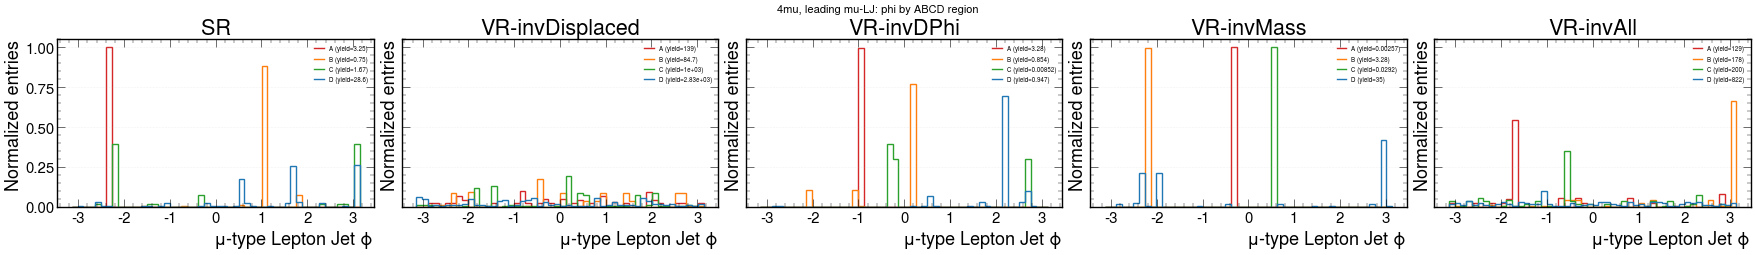

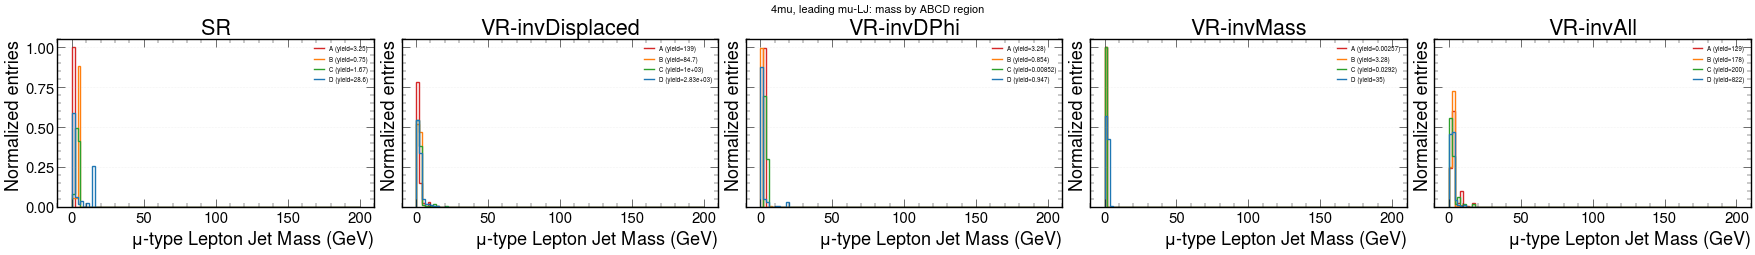

### 4mu, subleading mu-LJ

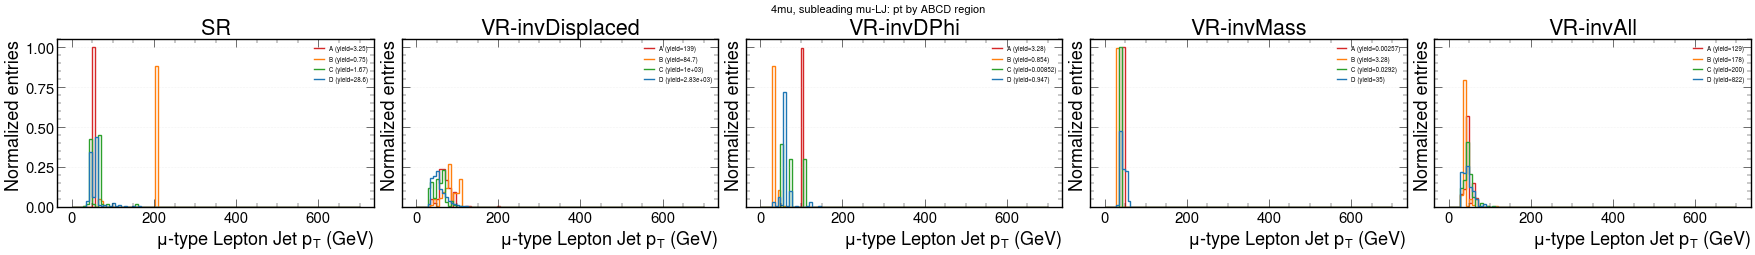

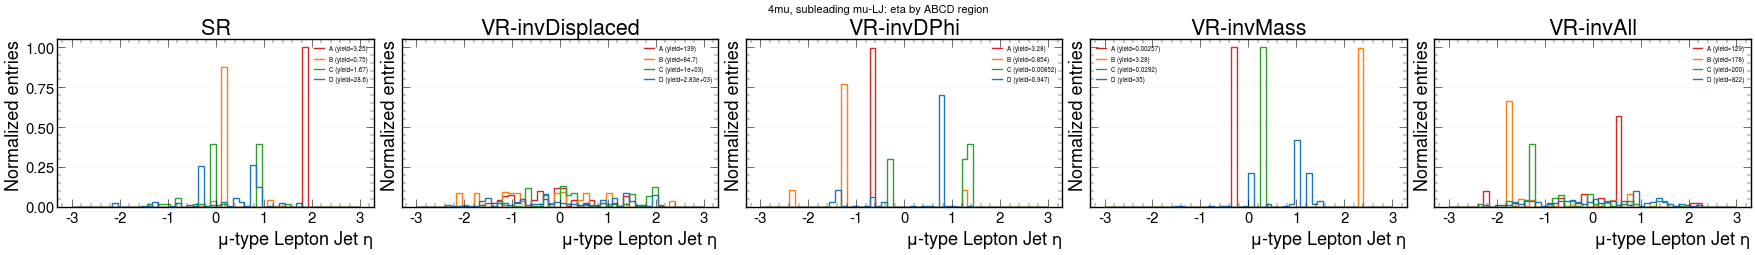

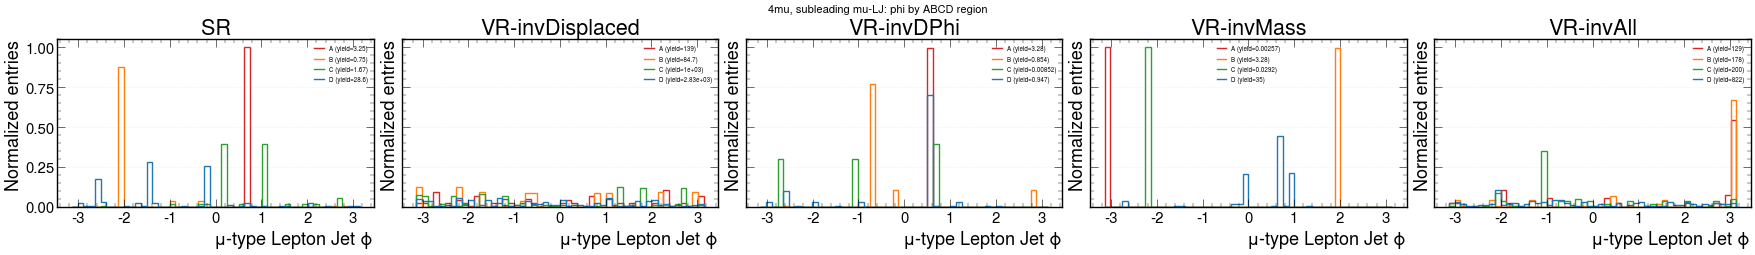

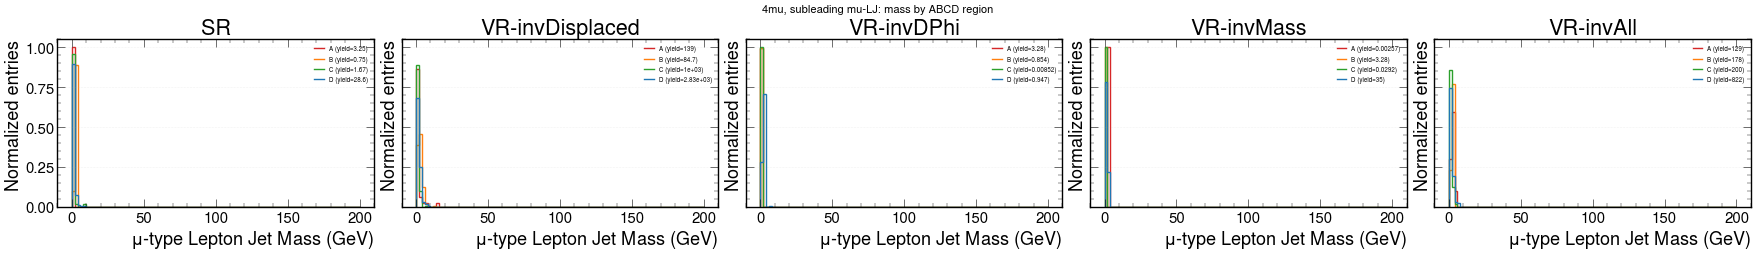

In [14]:
KINEMATIC_VARIABLES = ("pt", "eta", "phi", "mass")
REGION_COLORS = {"A": "#D62728", "B": "#FF7F0E", "C": "#2CA02C", "D": "#1F77B4"}

def combined_kinematic_histogram(topology, role, variable, selection, region):
    role_suffix = TOPOLOGY_CONFIG[topology]["roles"][role]
    histogram_name = f"abcd_{role_suffix}_{variable}"
    channel = TOPOLOGY_CONFIG[topology]["channels"][selection]
    total = None
    for sample in SAMPLES:
        histogram = out[sample]["hists"][histogram_name][{
            "channel": channel,
            "abcd_region": hist.loc(ABCD_REGIONS[region]),
        }]
        total = histogram.copy() if total is None else total + histogram
    return total

def folded_1d_values(histogram):
    values = np.asarray(histogram.values(flow=True), dtype=float)
    folded = values[1:-1].copy()
    folded[0] += values[0]
    folded[-1] += values[-1]
    return folded

def plot_abcd_kinematics(topology, role, variable):
    fig, axes = plt.subplots(
        1, len(SELECTIONS), figsize=(7 * len(SELECTIONS), 5),
        sharey=True, constrained_layout=True,
    )
    for ax, selection in zip(axes, SELECTIONS):
        for region in ABCD_REGIONS:
            histogram = combined_kinematic_histogram(topology, role, variable, selection, region)
            values = folded_1d_values(histogram)
            edges = np.asarray(histogram.axes[0].edges)
            integral = np.asarray(histogram.values(flow=True), dtype=float).sum()
            if integral > 0:
                values = values / integral
            ax.stairs(
                values, edges, label=f"{region} (yield={integral:.3g})",
                color=REGION_COLORS[region], linewidth=2,
            )
        ax.set(
            title=selection,
            xlabel=histogram.axes[0].label or variable,
            ylabel="Normalized entries",
        )
        ax.grid(axis="y", linestyle=":", alpha=0.3)
        ax.legend(frameon=False, fontsize=9)
    fig.suptitle(f"{topology}, {role}: {variable} by ABCD region", fontsize=16)
    plt.show()
    plt.close(fig)

for topology, config in TOPOLOGY_CONFIG.items():
    for role in config["roles"]:
        display(Markdown(f"### {topology}, {role}"))
        for variable in KINEMATIC_VARIABLES:
            plot_abcd_kinematics(topology, role, variable)


## Optional exports

Uncomment only when persistent CSV products are needed. Notebook execution itself does not write analysis tables.

In [15]:
# EXPORT_DIR = study_dir / "ABCD_landing_mother_tables"
# EXPORT_DIR.mkdir(parents=True, exist_ok=True)
# landing_summary.to_csv(EXPORT_DIR / "landing_summary.csv")
# for topology, table in sample_landing_yields.items():
#     table.to_csv(EXPORT_DIR / f"{topology}_sample_landing_yields.csv")
# for topology, role_tables in mother_yields_by_source.items():
#     for role, table in role_tables.items():
#         safe_role = role.replace(" ", "_").replace("-", "")
#         table.to_csv(EXPORT_DIR / f"{topology}_{safe_role}_mother_yields_by_source.csv")